# PCLab#3 - Group 4 - Claas Boumans Giuliano Ciaramella Theodor Nissen-Meyer

**20598 – Finance with Big Data · PC Lab #3: Creating a Factor from Text Data**

*Time required: approximately 10 hours. Difficulty: 8 out of 10. (excl. optional tasks)*

## 0. Setup

In [ ]:
# import necessary liabries
import os
import io
import glob
import html
import time
import logging
import zipfile
from collections import Counter
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.contingency_tables import mcnemar
from scipy import stats
import requests

import emoji
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers.utils import logging as hf_logging

pd.set_option("display.float_format", "{:,.4f}".format)
pd.set_option("display.max_colwidth", 150)                   # show whole messages in tables
hf_logging.set_verbosity_error()                              # hide the model-loading reports
hf_logging.disable_progress_bar()
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)  # and the Hub's rate-limit notice
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

DATA_FOLDERS = ["Data from 2010", "UnlabelledDataset_2"]           # the StockTwits files from BBoard
PRICE_FILE = "sp500_close_2010-01-01_to_2020-12-31.csv"            # S&P 500 closes downloaded in PC Lab #2
SEED = 42              # fixed random seed, so every run draws the same sample
MAX_TICKERS = 5        # messages naming more tickers are lists (screeners, watch lists), not opinions
SAMPLE_SIZE = 200_000  # messages scored by both transformers in Task #3

In [8]:
# Chart theme inspired by The Economist: white background, horizontal gridlines,
# bold left-aligned titles, red rule on top, the magazine's blue/teal palette.
ECONOMIST_RED = "#E3120B"
ECONOMIST_COLORS = ["#006BA2", "#3EBCD2", "#379A8B", "#EBB434", "#B4BA39",
                    "#9A607F", "#D1B07C", "#758D99", "#DB444B"]

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.prop_cycle": plt.cycler(color=ECONOMIST_COLORS),
    "axes.grid": True,
    "axes.grid.axis": "y",              # horizontal gridlines only
    "grid.color": "#D0D0D0",
    "axes.axisbelow": True,             # gridlines behind the data
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.titlelocation": "left",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "ytick.left": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "legend.frameon": False,
    "lines.linewidth": 1.6,
})

ECONOMIST_BLUES = LinearSegmentedColormap.from_list("economist_blues", ["#C5E4F0", "#3EBCD2", "#006BA2", "#0C2A4A"])
ECONOMIST_DIVERGING = LinearSegmentedColormap.from_list("economist_diverging", ["#DB444B", "white", "#006BA2"])
SENTIMENT_COLORS = {"negative": ECONOMIST_COLORS[8], "neutral": ECONOMIST_COLORS[7], "positive": ECONOMIST_COLORS[0]}


def show():
    '''Add the red rule and tag on top of the current figure, then display it.'''
    fig = plt.gcf()
    fig.tight_layout()
    fig.add_artist(plt.Line2D([0, 1], [1.02, 1.02], transform=fig.transFigure, color=ECONOMIST_RED, lw=1.5))
    fig.add_artist(plt.Rectangle((0, 1.02), 0.035, 0.015, transform=fig.transFigure, color=ECONOMIST_RED, clip_on=False))
    plt.show()

## Task #1 – Import the data and describe the sample
StockTwits messages, one CSV per symbol: 20 files in `Data from 2010` and five larger ones in `UnlabelledDataset_2`. Each row holds the file's symbol, the message, a UTC timestamp (converted to New York time, the exchange's clock), the user id and the message id. **There is no sentiment label**: all sentiment in this notebook comes from our own models (Task #3).

In [9]:
def load_stocktwits(folders=DATA_FOLDERS):
    '''Read every stocktwits_*.csv of the folders into one frame, with timestamps in New York time.'''
    paths = [path for folder in folders for path in sorted(glob.glob(os.path.join(folder, "stocktwits_*.csv")))]
    raw = pd.concat([pd.read_csv(path, dtype={"user": "int32"}) for path in paths], ignore_index=True)
    raw["symbol"] = raw["symbol"].astype("category")
    raw["datetime"] = pd.to_datetime(raw["datetime"], utc=True).dt.tz_convert("America/New_York")
    return raw


raw = load_stocktwits()
N_ROWS = len(raw)
print(f"{N_ROWS:,} rows from {raw['symbol'].nunique()} files, {raw['datetime'].min():%Y-%m-%d} to {raw['datetime'].max():%Y-%m-%d}")
print("Missing values:", int(raw.isna().sum().sum()))
raw.head(3)

6,483,233 rows from 25 files, 2009-07-10 to 2020-07-23
Missing values: 0


,symbol,message,datetime,user,message_id
0,ADBE,$ADBE buying on Monday along for the ride,2020-07-11 03:05:17-04:00,3755147,226982917
1,ADBE,$ADBE Red to Green move: -1.16 percentage to 0.38 percentage https://www.sleekoptions.com/sleekscan.aspx?did=ADBE,2020-07-10 23:25:44-04:00,1442893,226960125
2,ADBE,Your daily News digest for Adobe $ADBE https://wsfriend.com/daily/news/ADBE/2020-07-10/,2020-07-10 17:44:41-04:00,732840,226885240


### 1.1 Data sanity check

**Check 1 – Duplicates.**

In [10]:
files_per_message = raw.groupby("message_id")["symbol"].nunique()

print(f"Exact duplicate rows                  : {raw.duplicated().sum():,}")
print(f"Messages stored in more than one file : {(files_per_message > 1).sum():,} (up to {files_per_message.max()} files)")
print(f"Unique messages                       : {len(files_per_message):,} of {N_ROWS:,} rows")

raw = raw.drop_duplicates()                   # the exact copies carry no information

Exact duplicate rows                  : 73,148
Messages stored in more than one file : 666,279 (up to 12 files)
Unique messages                       : 5,564,920 of 6,483,233 rows


**Decision:** one observation per `message_id`. A message naming \$AAPL and \$TSLA sits in both files. Counting it twice would inflate the attention of exactly the stocks that are discussed together.

**Check 2 – Is each file about its symbol?** StockTwits tags stocks with cashtags (\$AAPL). `extract_tickers` reads them and maps share classes and renamed tickers to today's ticker, because the S&P 500 list of PC Lab #2 (Task #4) is today's: Facebook was \$FB until 2022, Booking \$PCLN until 2018.

In [11]:
CASHTAG = r"(?<![\w$])\$([A-Za-z]{1,6}(?:[./-][A-Za-z]{1,2})?)(?![\w])"   # $AAPL, $brk.b, $BRK/B, but not $100 or US$
URL = r"https?://\S+|www\.\S+"
MENTION = r"@\w+"

# Share classes of one company, and old tickers -> today's ticker
TICKER_ALIASES = {"GOOG": "GOOGL", "BRK.A": "BRK.B", "BRKB": "BRK.B", "FOX": "FOXA", "NWS": "NWSA",
                  "FB": "META", "PCLN": "BKNG", "ANTM": "ELV", "BK": "BNY", "SQ": "XYZ", "DPS": "KDP",
                  "HRS": "LHX", "UTX": "RTX", "BBT": "TFC", "MYL": "VTRS", "ABC": "COR", "WLTW": "WTW",
                  "TMK": "GL", "HCN": "WELL", "BLL": "BALL", "RE": "EG", "PKI": "RVTY", "FLT": "CPAY",
                  "DISCA": "WBD", "DISCK": "WBD", "SYMC": "GEN", "NLOK": "GEN", "PX": "LIN", "JEC": "J",
                  "KFT": "MDLZ", "HCP": "DOC", "PEAK": "DOC"}


def to_company(ticker):
    '''One ticker per company: BRK/B -> BRK.B, GOOG -> GOOGL, FB -> META.'''
    ticker = ticker.upper().replace("/", ".").replace("-", ".")
    return TICKER_ALIASES.get(ticker, ticker)


def extract_tickers(texts):
    '''The companies named with a $ sign in each message, as a sorted list of today's tickers.'''
    return texts.str.findall(CASHTAG).map(lambda tags: sorted({to_company(tag) for tag in tags}))


def file_audit(raw):
    '''Per file: share of messages naming the file's company, and the company named most often instead.'''
    rows = []

    for symbol, file in raw.groupby("symbol", observed=True):
        tickers = extract_tickers(file["message"])
        names_own = tickers.map(lambda t: to_company(symbol) in t)
        instead = Counter(t for ts in tickers[~names_own] for t in ts).most_common(1)
        rows.append({"file": symbol, "messages": len(file), "names own ticker": names_own.mean(),
                     "named most often instead": instead[0][0] if instead else "",
                     "first message": file["datetime"].min().date()})

    return pd.DataFrame(rows).set_index("file").sort_values("names own ticker")


audit = file_audit(raw)
audit

,messages,names own ticker,named most often instead,first message
file,,,,
JNJ,39036,0.3206,T,2009-08-21
BRK.B,33718,0.3724,BAC,2010-02-23
UNH,16136,0.3994,V,2009-09-29
BAC,165821,0.4810,AMZN,2009-07-13
FB,112115,0.4962,DIS,2009-08-31
INTC,15502,0.5077,HD,2009-09-16
WMT,13677,0.5083,VZ,2009-09-11
SPY,153794,0.5592,VIX,2009-09-09
BRK.A,11302,0.9584,BRKA,2009-11-05


**Check 3 – Is the coverage continuous?**

Months without a message, June 2012 to June 2020: WMT 54, INTC 46, FB 34, UNH 29, GOOGL 24, GOOG 20, JNJ 15, BRK.B 15, BAC 13, SPY 8, V 1


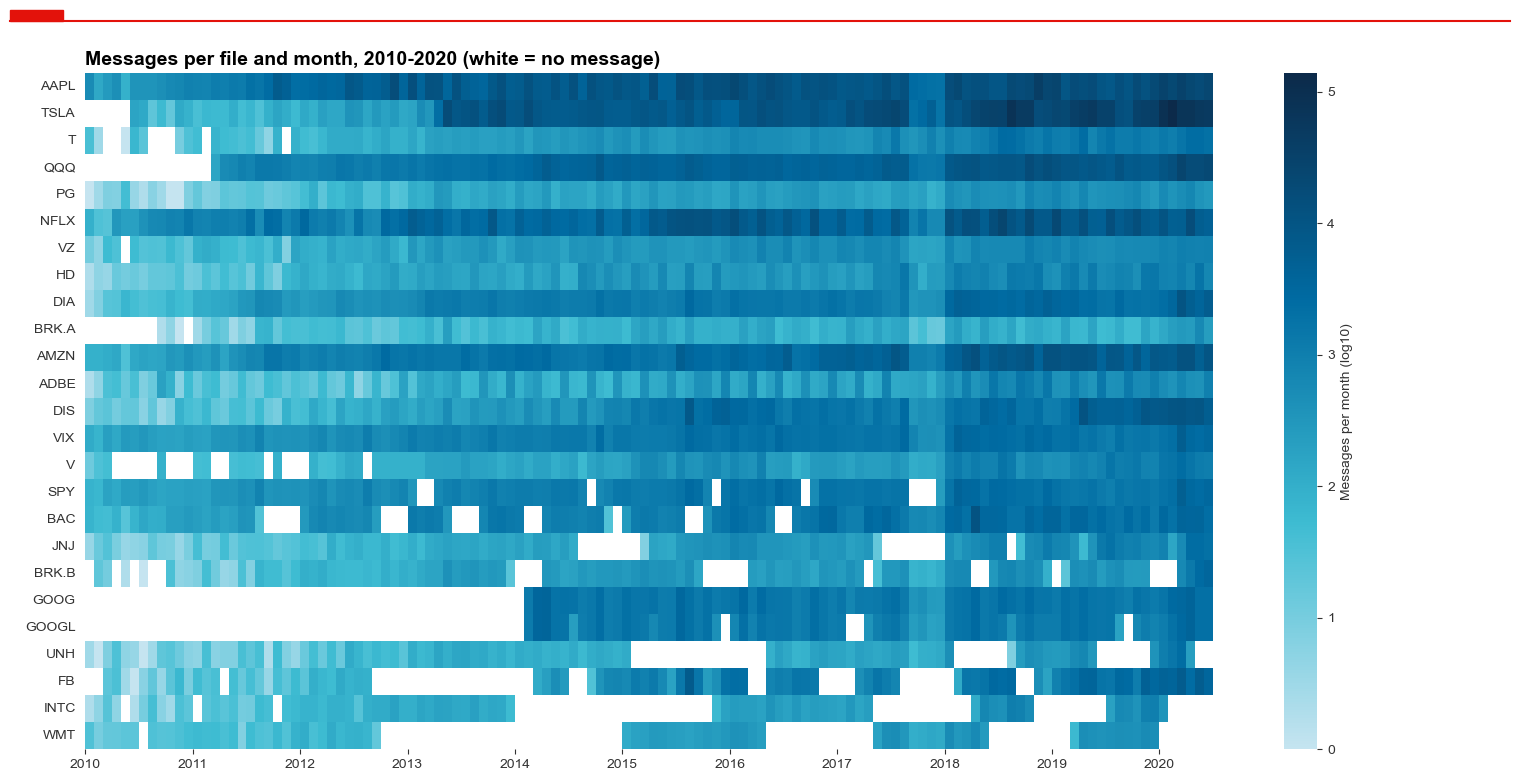

In [12]:
month_of = raw["datetime"].dt.tz_localize(None).dt.to_period("M")
per_month = (raw.groupby(["symbol", month_of], observed=True).size().unstack(fill_value=0)
                .reindex(columns=pd.period_range("2010-01", "2020-06", freq="M"), fill_value=0))
empty = per_month.loc[:, "2012-06":].eq(0).sum(axis=1).sort_values()          # since Facebook's IPO, 97 months
per_month = per_month.loc[empty.index]
print("Months without a message, June 2012 to June 2020:",
      ", ".join(f"{symbol} {n}" for symbol, n in empty[empty > 0].sort_values(ascending=False).items()))

fig, ax = plt.subplots(figsize=(15, 7.5))
sns.heatmap(np.log10(per_month.where(per_month > 0)), cmap=ECONOMIST_BLUES, ax=ax,
            cbar_kws={"label": "Messages per month (log10)"})
years = [i for i, month in enumerate(per_month.columns) if month.month == 1]
ax.set_xticks(years, [per_month.columns[i].year for i in years], rotation=0)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Messages per file and month, 2010-2020 (white = no message)")
plt.grid(False)
show()

**Check 4 – Text encoding.**

In [13]:
messages = (raw.drop_duplicates("message_id").drop(columns="symbol")
               .sort_values("message_id").reset_index(drop=True))     # ids grow over time: chronological order
del raw, month_of

ENTITY = r"&(?:#\d+|[a-z]+);"
has_entity = messages["message"].str.contains(ENTITY)
example = messages.loc[messages["message"].str.contains("&#39;"), "message"].iloc[0]

messages["text"] = messages.pop("message").map(html.unescape)          # &#39; -> '   &amp; -> &   &quot; -> "
encoded_twice = messages["text"].str.contains(ENTITY)

print(f"Messages with HTML entities : {has_entity.mean():.1%}")
print("Before:", example[:100])
print("After :", html.unescape(example)[:100])
print(f"Still encoded after decoding: {encoded_twice.sum():,} messages ({encoded_twice.mean():.2%}), encoded twice, "
      f"e.g. {messages.loc[encoded_twice, 'text'].iloc[0][:45]!r}")

Messages with HTML entities : 20.1%
Before: @rosswhiting that&#39;s because Apple&#39;s ticker is $AAPL, not $APPL
After : @rosswhiting that's because Apple's ticker is $AAPL, not $APPL
Still encoded after decoding: 1,961 messages (0.04%), encoded twice, e.g. '@dustin I&#39;m long $aapl or at least until '


**Check 5 – Automated accounts.** Bots post screener results, option-flow alerts and insider filings from a fixed template. We mask numbers, tickers and links and flag users with at least 200 messages of which fewer than half are distinct.

In [14]:
def find_bots(messages, min_messages=200, max_unique_share=0.5):
    '''Users whose messages are mostly one template once numbers, tickers and links are masked.'''
    template = (messages["text"].str.lower()
                .str.replace(URL, "<link>", regex=True)
                .str.replace(CASHTAG, "<ticker>", regex=True)
                .str.replace(r"\d+(?:[.,:]\d+)*", "<number>", regex=True)
                .str.replace(r"\s+", " ", regex=True))
    templates = pd.DataFrame({"user": messages["user"], "template": template})
    users = templates.groupby("user")["template"].agg(["size", "nunique"])
    users["unique share"] = users["nunique"] / users["size"]
    bots = users[(users["size"] >= min_messages) & (users["unique share"] < max_unique_share)].sort_values("size", ascending=False)

    typical = templates[templates["user"].isin(bots.index)].groupby("user")["template"].agg(lambda t: t.mode().iloc[0])
    return bots.assign(**{"most frequent template": typical})


bots = find_bots(messages)
messages["bot"] = messages["user"].isin(bots.index)

print(f"{len(bots)} automated accounts wrote {messages['bot'].sum():,} messages ({messages['bot'].mean():.1%})")
bots.head(8).drop(columns="nunique").assign(**{"most frequent template": lambda b: b["most frequent template"].str[:100]})

117 automated accounts wrote 202,461 messages (3.6%)


,size,unique share,most frequent template
user,,,
47688,38975,0.0427,<ticker> has an average volume of <number>. this is a good sign as it is always nice to have a liqui
800154,17197,0.2475,price returns vs expected daily move <ticker> <ticker> <ticker> <ticker> <ticker> <ticker> <ticker>
1442893,11376,0.0700,peak profit for the last <number> expired option alerts for <ticker> <number> | <number> | <number>
210967,10167,0.2600,major owner of google inc. just disposed of <number> shares <link> <ticker>
917666,7199,0.1575,<ticker> <ticker> <ticker> <ticker> <ticker> <ticker> <ticker> <ticker> nyse market internals summar
850976,5858,0.3732,top bullish flow (a/o<number>pmest): <ticker> <ticker> <ticker> <ticker> <ticker>
313661,4480,0.2458,dow stocks at x-day high [<number>-mar]: <number>-day: <number>% <number>-day: <number>% <number>-da
739441,4034,0.2372,<ticker> today's <number> top/bottom percent net change performers on the nasdaq. $es_f <ticker> @cq


**Check 6 – Messages without an opinion.** Messages with nothing but tickers, links and numbers express no view, and messages naming more than five tickers are lists (watch lists, screeners, newsletters) that belong to no single stock.

In [15]:
messages["tickers"] = extract_tickers(messages["text"])
messages["n_tickers"] = messages["tickers"].str.len()

leftover = (messages["text"].str.replace(CASHTAG, "", regex=True).str.replace(URL, "", regex=True)
            .str.replace(MENTION, "", regex=True).str.replace(r"[\x00-\x40\x5b-\x60\x7b-\x7f]", "", regex=True))
messages["no_words"] = leftover.eq("")          # nothing left but ASCII digits and punctuation (emojis count as words)
del leftover

print(f"Only tickers, links or numbers : {messages['no_words'].mean():.1%}   e.g. {messages.loc[messages['no_words'], 'text'].iloc[1000]!r}")
print(f"More than {MAX_TICKERS} tickers          : {(messages['n_tickers'] > MAX_TICKERS).mean():.1%}   e.g. {messages.loc[messages['n_tickers'] > MAX_TICKERS, 'text'].iloc[1000][:80]!r}")
print(f"No ticker at all               : {(messages['n_tickers'] == 0).mean():.2%}")

Only tickers, links or numbers : 2.7%   e.g. '$AAPL, $PCLN, $AMZN.....'
More than 5 tickers          : 2.9%   e.g. 'VIDEO: charting the week in review & week ahead  http://stks.co/3uEI $spx $spy $'
No ticker at all               : 0.01%


**What we keep.** The filters are applied in sequence, so each message is counted once.

In [16]:
is_human = ~messages["bot"]
has_words = is_human & ~messages["no_words"]
keep = has_words & messages["n_tickers"].between(1, MAX_TICKERS)

waterfall = pd.DataFrame({"messages": [N_ROWS, len(messages), -(~is_human).sum(), -(is_human & ~has_words).sum(),
                                       -(has_words & ~keep).sum(), keep.sum()]},
                         index=["rows in the 25 files", "unique messages", "- written by automated accounts",
                                "- only tickers, links or numbers", f"- no ticker or more than {MAX_TICKERS} tickers",
                                "clean corpus"])
waterfall["share of unique messages"] = (waterfall["messages"].abs() / len(messages)).iloc[1:]

corpus = messages[keep].drop(columns=["bot", "no_words"]).reset_index(drop=True)
corpus["text"] = corpus["text"].map(html.unescape)                    # second pass for the messages encoded twice
del messages
waterfall.style.format({"messages": "{:,.0f}", "share of unique messages": "{:.1%}"}, na_rep="")

,messages,share of unique messages
rows in the 25 files,"6,483,233",
unique messages,"5,564,920",100.0%
- written by automated accounts,"-202,461",3.6%
"- only tickers, links or numbers","-148,625",2.7%
- no ticker or more than 5 tickers,"-136,628",2.5%
clean corpus,"5,077,206",91.2%


**Comments – Task #1 (sanity check)**

- **Duplicates.** 14% of the rows repeat a message: 73,148 exact copies, and 666,279 messages stored in two to twelve files because they name several of the 25 symbols.
- **Eight files are only partly about their symbol.** 44% (SPY) to 68% (JNJ) of their rows name another company, mostly a single other symbol (column "named most often instead"), and the FB file even starts in 2009, three years before Facebook's IPO, with messages about Disney. The collection evidently mixed up the pages of two symbols, so we never use the file name: a message's stocks are the cashtags in its text. Users are imprecise too (\$BRKA, \$ATT, or \$QQQQ, the Nasdaq ETF's ticker until 2011).
- **Coverage has gaps.** Eleven files miss whole months (up to 54 of 97 for WMT; GOOG and GOOGL start only in February 2014), and every file thins out from September to December 2017 (the pale band): 7,000 to 10,000 clean messages a month against 50,000 to 63,000 before and after (figure in 1.2). These are collection gaps, not a loss of interest, so Task #4 measures attention against each stock's own history and against the other stocks of the same month.
- **Encoding.** A fifth of the messages contain HTML entities and 1,961 are encoded twice. Decoding twice fixes both.
- **Bots.** 117 accounts wrote 3.6% of the messages. They react to prices mechanically and would manufacture a link between attention and returns.
- **No opinion.** 2.7% of the messages contain only tickers, links or numbers, and 2.5% name no ticker or more than five.

### 1.2 The clean sample
We count as words the tokens containing letters, excluding tickers, links and user names.

In [47]:
corpus["words"] = (corpus["text"].str.replace(URL, " ", regex=True).str.replace(CASHTAG, " ", regex=True)
                   .str.replace(MENTION, " ", regex=True).str.count(r"[A-Za-z]+(?:['’][A-Za-z]+)*"))
year = corpus["datetime"].dt.year
messages_per_user = corpus["user"].value_counts()

print(f"Messages        : {len(corpus):,}, {corpus['datetime'].min():%Y-%m-%d} to {corpus['datetime'].max():%Y-%m-%d}")
print(f"Users           : {len(messages_per_user):,} - the top 1% write {messages_per_user.head(len(messages_per_user) // 100).sum() / len(corpus):.0%} of the messages")
print(f"Companies named : {corpus['tickers'].explode().nunique():,} - tickers per message {corpus['n_tickers'].mean():.2f} on average")
print(f"Words / message : mean {corpus['words'].mean():.1f}, median {corpus['words'].median():.0f}, 95th percentile {corpus['words'].quantile(0.95):.0f}, max {corpus['words'].max()}")

pd.DataFrame({
    "messages": corpus.groupby(year).size(),
    "users": corpus.groupby(year)["user"].nunique(),
    "words per message (median)": corpus.groupby(year)["words"].median(),
    "longer than 140 characters": corpus["text"].str.len().gt(140).groupby(year).mean(),
    "with a link": corpus["text"].str.contains(URL).groupby(year).mean(),
    "with an emoji": corpus["text"].str.contains(r"[\U0001F300-\U0001FAFF☀-➿]").groupby(year).mean(),
}).T.map(lambda v: f"{v:,.0f}" if v >= 1 else f"{v:.1%}")

Messages        : 5,077,206, 2009-07-10 to 2020-07-23
Users           : 130,024 - the top 1% write 46% of the messages
Companies named : 13,533 - tickers per message 1.50 on average
Words/message : mean 13.1, median 11, 95th percentile 27, max 247


datetime,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
messages,"2,721","20,069","69,243","128,381","300,963","348,875","450,227","479,699","401,142","930,851","935,244","1,009,791"
users,281,"1,443","3,562","6,467","10,547","13,611","17,578","20,976","20,701","35,258","35,903","51,023"
words per message (median),10,11,12,12,12,11,11,10,10,11,10,10
longer than 140 characters,0.1%,0.1%,0.1%,0.1%,0.1%,0.0%,0.0%,3.3%,5.9%,4.5%,16.8%,24.0%
with a link,21.1%,21.3%,27.2%,19.4%,21.9%,25.6%,16.1%,15.4%,16.6%,9.2%,11.1%,9.7%
with an emoji,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.6%,2.6%,5.1%,8.8%,11.0%


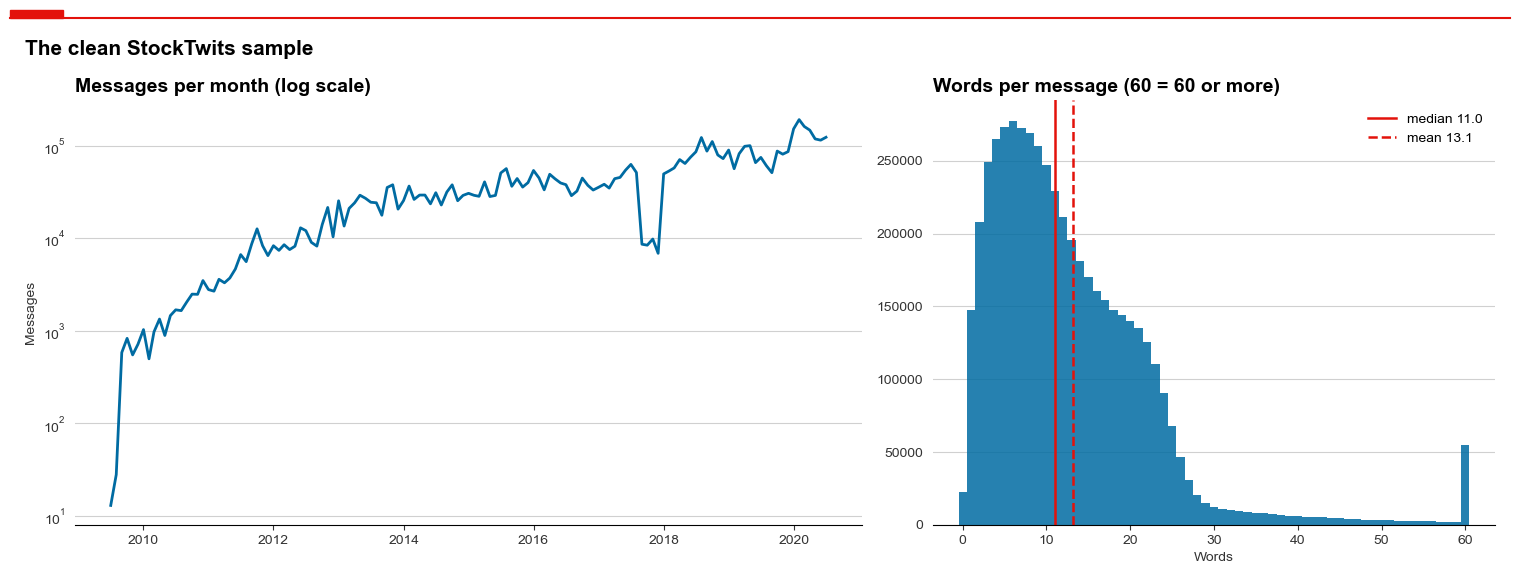

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1.4, 1]})

monthly = corpus.groupby(corpus["datetime"].dt.tz_localize(None).dt.to_period("M")).size()
axes[0].plot(monthly.index.to_timestamp(), monthly, color=ECONOMIST_COLORS[0], lw=2)
axes[0].set_yscale("log")
axes[0].set_title("Messages per month (log scale)")
axes[0].set_ylabel("Messages")

axes[1].hist(corpus["words"].clip(upper=60), bins=np.arange(0, 62) - 0.5, color=ECONOMIST_COLORS[0], alpha=0.85)
for value, label, style in [(corpus["words"].median(), "median", "-"), (corpus["words"].mean(), "mean", "--")]:
    axes[1].axvline(value, color=ECONOMIST_RED, lw=1.8, ls=style, label=f"{label} {value:.1f}")
axes[1].set_title("Words per message (60 = 60 or more)")    # hard cut-off
axes[1].set_xlabel("Words")
axes[1].legend()

for ax in axes:
    ax.grid(False, axis="x")
fig.suptitle("The clean StockTwits sample", x=0.01, ha="left", fontsize=15, fontweight="bold")
show()

**Comments – Task #1 (description)**

- **Concentrated activity.** The top 1% of the 130,024 users write 46% of the messages: some 1,300 voices shape what "StockTwits thinks".
- **Fast growth.** From 2,700 messages in 2009 to 935,000 in 2019. January to July 2020 alone (1.01 million, with the COVID crash and the boom in retail trading) exceeds every full year.
- **Short messages.** Median 11 words, mean 13.1. Until 2015 almost no message exceeds 140 characters (0.1%), consistent with a 140-character limit. By 2020 24% do while the median stays at 10 to 12 words, so the long tail is recent.
- **A changing style.** Links fall from a fifth of the messages (2009-2014) to a tenth (2020) and emojis rise from none before 2016 to 11%, which matters for the choice of sentiment model (3.1).
- The 13,533 tickers named go far beyond the S&P 500: small caps, ETFs, cryptocurrencies (\$BTC.X). The **average sentiment** follows in 3.3.

## Task #2 – Cleaning and visualization
Task #1 chose the messages. Task #2 cleans their text for word counts and word clouds. `clean_text` uses vectorised pandas string methods and processes the five million messages:

| Step | Illustrative Example |
|---|---|
| lower case - links and @user names removed | `@trader99 see https://...` → `see` |
| cashtags removed (StockTwits uses \$ instead of #) | `$TSLA` → ` ` |
| hashtags kept as words | `#earnings` → `earnings` |
| emoticons and emojis written as words | `:)` → `smile`, 🚀 → `rocket` |
| apostrophes dropped, elongated words shortened | `don't` → `dont`, `soooo` → `soo` |
| numbers and punctuation removed | `+12.5%!!` → ` ` |

Then **tokenisation** (split on spaces, one-letter tokens dropped), **stopword removal** and **lemmatisation** (WordNet, as a noun, then as a verb: *puts* → *put*, *bought* → *buy*). Stopwords go first because the lemmatiser turns *was* into *wa*. We keep *not, no, up, down, over, under, off* and *out* although NLTK lists them: in a trading forum they carry the message ("not selling", "up 5%", "puts are down").

In [48]:
EMOTICONS = {r"[:;=]-?[)\]dp]|\(-?[:;=]": " smile ", r"[:;=]-?[(\[]": " sad ", r"<3(?!\d)": " heart "}
KEEP = {"no", "not", "nor", "up", "down", "above", "below", "over", "under", "off", "out", "against"}
STOPWORDS = (set(stopwords.words("english")) - KEEP) | {"im", "ive", "id", "youre", "thats", "u", "ur", "rt", "amp"}
lemmatizer = WordNetLemmatizer()


def demojize(text):
    '''Turns Emojis into words: 🚀 -> rocket'''
    return emoji.demojize(text, delimiters=(" ", " "))


def clean_text(texts):
    '''The cleaning steps of the table above, for a Series of messages.'''
    texts = texts.str.lower()
    texts = texts.str.replace(URL, " ", regex=True).str.replace(MENTION, " ", regex=True)
    texts = texts.str.replace(CASHTAG, " ", regex=True)
    texts = texts.str.replace(r"#(\w+)", r" \1 ", regex=True)
    for pattern, word in EMOTICONS.items():
        texts = texts.str.replace(pattern, word, regex=True)
    non_ascii = texts.str.contains(r"[^\x00-\x7f]")                     # only these can contain emojis
    texts.loc[non_ascii] = texts.loc[non_ascii].map(demojize)
    texts = texts.str.replace(r"[’'`]", "", regex=True)
    texts = texts.str.replace(r"([a-z])\1{2,}", r"\1\1", regex=True)
    return texts.str.replace(r"[^a-z_]+", " ", regex=True).str.strip()


@lru_cache(maxsize=None)
def lemmatize(word):
    '''WordNet lemma, first as a noun and then as a verb.'''
    return lemmatizer.lemmatize(lemmatizer.lemmatize(word), "v")


def tokenize(cleaned):
    '''Words of a cleaned message, without stopwords and one-letter tokens, lemmatised.'''
    return [lemmatize(word) for word in cleaned.split() if len(word) > 1 and word not in STOPWORDS]

In [20]:
# The pipeline on a few messages that need each step
cases = [r"n['’]t\b", r"([a-z])\1{3,}", r"[:;]-?\)", "\U0001F680", r"#[A-Za-z]{4,}"]
examples = pd.concat([corpus.loc[corpus["text"].str.count(case) > 0, "text"].iloc[[5]] for case in cases])
pd.DataFrame({"message": examples.str[:90], "words after cleaning": clean_text(examples).map(tokenize)}).set_index("message")

,words after cleaning
message,
Neglected to post earlier my cover order for 1/4 of $V filled 7010. POS won't die,"[neglect, post, earlier, cover, order, fill, po, wont, die]"
"$SPY is hovering along the longterm uptrend line, below 104 and there is sssppppaacceee","[hover, along, longterm, uptrend, line, below, ssppaaccee]"
"RT good call, should be over $200 by earnings :) @AnneMarie2006 Long $AAPL 182.63","[good, call, over, earnings, smile, long]"
$TSLA $SCTY Ambitious. It's a shame the wealthiest of snobs will be the 1st to colonize th,"[ambitious, shame, wealthiest, snob, st, colonize, planet, st, destroy, earth, st, mar, rocket]"
Holding these: $C $ETFC $GOOG - Waiting for these to pullback to get back in: $AAPL in 17,"[hold, wait, pullback, get, back, mid, think, amateurinvestor]"


**Number of unique words** after each step, counted over the full corpus in chunks to save memory.

In [21]:
def vocabulary_by_step(texts, chunk_size=500_000):
    '''Unique words after each cleaning step, and the frequency of the final lemmas.'''
    raw_words, cleaned_words, content_words, lemmas = set(), Counter(), Counter(), Counter()

    for start in range(0, len(texts), chunk_size):
        chunk = texts.iloc[start:start + chunk_size]
        for message in chunk:
            raw_words.update(message.split())
        for cleaned in clean_text(chunk):
            words = [word for word in cleaned.split() if len(word) > 1]
            cleaned_words.update(words)
            content = [word for word in words if word not in STOPWORDS]
            content_words.update(content)
            lemmas.update(lemmatize(word) for word in content)

    steps = pd.Series({"raw text, split on spaces": len(raw_words), "after cleaning": len(cleaned_words),
                       "after stopword removal": len(content_words), "after lemmatisation": len(lemmas),
                       "  of which used at least 10 times": sum(n >= 10 for n in lemmas.values()),
                       "  of which used only once": sum(n == 1 for n in lemmas.values())}, name="unique words")
    return steps, lemmas


vocabulary, lemma_counts = vocabulary_by_step(corpus["text"])
print(f"{sum(lemma_counts.values()):,} words in total after cleaning")
vocabulary.to_frame().map("{:,}".format)

41,576,543 words in total after cleaning


,unique words
"raw text, split on spaces","2,585,996"
after cleaning,"238,010"
after stopword removal,"237,871"
after lemmatisation,"215,234"
of which used at least 10 times,"33,441"
of which used only once,"121,619"


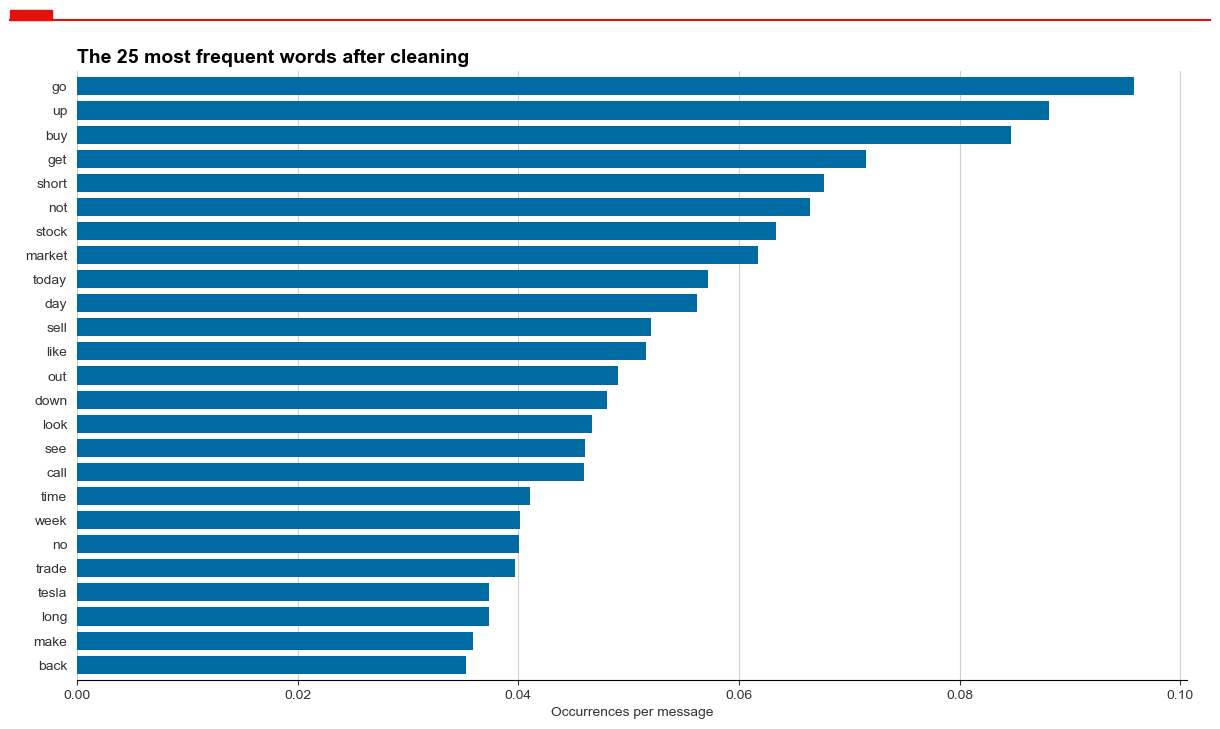

In [22]:
top_words = pd.Series(dict(lemma_counts.most_common(25))) / len(corpus)

ax = top_words.sort_values().plot.barh(figsize=(12, 7), color=ECONOMIST_COLORS[0], width=0.75)
ax.set_title("The 25 most frequent words after cleaning")
ax.set_xlabel("Occurrences per message")
ax.grid(False, axis="y")
ax.grid(True, axis="x", color="#D0D0D0")
show()

**Comments – Task #2**

- **215,234 unique words** remain after cleaning, stopword removal and lemmatisation, from 2.59 million raw strings, mostly links, tickers, numbers and spelling variants. Stopword removal barely shrinks the vocabulary (139 words) but removes the most frequent tokens.
- **The vocabulary in use is far smaller:** 33,441 words appear at least ten times, while 57% appear only once (typos, elongations such as *ssppaaccee*, names, tickers without \$), the long tail typical of social media.
- **The most frequent words are trading vocabulary** (*go, up, buy, short, stock, market, sell, call, long*) and time (*today, day, week*). Five of the top 25 (*up, not, out, down, no*) are on NLTK's stopword list.
- Rule-based cleaning has limits: "POS" becomes *po* and "1st" leaves *st*. Such tokens are rare.

The word clouds by sentiment need the labels of Task #3 and follow in 3.8.

## Task #3 – Sentiment analysis
### 3.1 Two pretrained transformers
Same architecture, different training:

| | Twitter-RoBERTa | FinBERT |
|---|---|---|
| Hugging Face model | `cardiffnlp/twitter-roberta-base-sentiment-latest` | `ProsusAI/finbert` |
| Language learnt from | 124 million tweets, 2018-2021 | Reuters financial news (TRC2) |
| Fine-tuned on | TweetEval: general tweets, labelled by crowd workers | Financial PhraseBank: news sentences, labelled by people with a finance background |
| Question it answers | Is the author happy or upset? | Is this good or bad news for an investor in the stock? |
| Vocabulary | byte-level BPE: emojis, slang and cashtags are encoded | WordPiece: every emoji becomes `[UNK]` |

Neither saw StockTwits, whose language is social (emojis, slang, irony) and whose content is financial: Twitter-RoBERTa knows the language, FinBERT the content. We compare two definitions of sentiment, not two implementations of one.

### 3.2 Scoring a random sample
Scoring all five million messages would unfortunately take too long. A random sample of 200,000 messages (3.9%) estimates any label share to within +/- 0.2 pp and the shares of a stock-year with 25,000 messages to within +/- 3 pp (95% intervals).

The transformers read the raw text, not the output of Task #2, because they rely on word order, negations and punctuation. We only decode the HTML and mask links and user names (`http`, `@user`), as Twitter-RoBERTa's preprocessing does.

In [45]:
MODELS = {"roberta": "cardiffnlp/twitter-roberta-base-sentiment-latest", "finbert": "ProsusAI/finbert"}
NAMES = {"roberta": "Twitter-RoBERTa", "finbert": "FinBERT"}
LABELS = ["negative", "neutral", "positive"]
SENTIMENT_CACHE = "sentiment_scores.csv"
DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"


def model_text(texts):
    '''Light cleaning for the transformers: user names and links masked, as in Twitter-RoBERTa's preprocessing.'''
    return (texts.str.replace(URL, "http", regex=True).str.replace(MENTION, "@user", regex=True)
                 .str.replace(r"\s+", " ", regex=True).str.strip())


def score_sentiment(texts, model_name, batch_size=64):
    '''Probabilities of negative, neutral and positive for each text, from one pretrained model.'''
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name).to(DEVICE).eval()
    columns = [model.config.id2label[i].lower() for i in range(model.config.num_labels)]   # the label order differs by model

    texts = list(texts)
    order = np.argsort([len(text) for text in texts])          # batches of similar length need less padding
    probabilities = np.zeros((len(texts), len(columns)), dtype=np.float32)
    with torch.inference_mode():
        for start in range(0, len(texts), batch_size):
            batch = order[start:start + batch_size]
            tokens = tokenizer([texts[i] for i in batch], padding=True, truncation=True, max_length=128, return_tensors="pt")
            probabilities[batch] = model(**tokens.to(DEVICE)).logits.softmax(dim=-1).cpu().numpy()

    return pd.DataFrame(probabilities, columns=columns)[LABELS]


def cached_scores(sample, cache=SENTIMENT_CACHE):
    '''Scores of both models for the sampled messages, stored on disk: the first run takes 30 to 60 minutes on a laptop.'''
    scores = pd.read_csv(cache) if os.path.exists(cache) else pd.DataFrame({"message_id": pd.Series(dtype="int64")})
    missing = sample[~sample["message_id"].isin(scores["message_id"])]

    if len(missing):
        print(f"Scoring {len(missing):,} messages on {DEVICE}...")
        new = pd.concat([score_sentiment(model_text(missing["text"]), name).add_prefix(f"{key}_")
                         for key, name in MODELS.items()], axis=1)
        new.insert(0, "message_id", missing["message_id"].to_numpy())
        scores = pd.concat([scores, new], ignore_index=True)
        scores.round(5).to_csv(cache, index=False)

    return sample.merge(scores, on="message_id", how="left", validate="one_to_one")


def add_labels(frame):
    '''Most likely label and net tone P(positive) - P(negative) for each model.'''
    for key in MODELS:
        probabilities = frame[[f"{key}_{label}" for label in LABELS]].to_numpy()
        frame[f"{key}_label"] = pd.Categorical(np.array(LABELS)[probabilities.argmax(axis=1)], categories=LABELS)
        frame[f"{key}_tone"] = frame[f"{key}_positive"] - frame[f"{key}_negative"]
    return frame


sample = corpus.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
sample = add_labels(cached_scores(sample))
print(f"{len(sample):,} messages scored. Missing scores: {int(sample['finbert_positive'].isna().sum())}")

200,000 messages scored. Missing scores: 0


### 3.3 Do the two models agree?
Each model returns the probabilities of *negative*, *neutral* and *positive*. The label is the most likely one. The **tone** $P(\text{positive}) - P(\text{negative}) \in [-1, 1]$ keeps the strength of the signal. Cohen's $\kappa$ measures agreement beyond chance: 0 for two independent draws with the same label shares, 1 for identical labels.

In [24]:
def cohen_kappa(table):
    '''Agreement beyond chance, from the joint distribution of two models' labels (shares summing to 1).'''
    table = table.to_numpy()
    observed, expected = np.trace(table), table.sum(axis=1) @ table.sum(axis=0)
    return (observed - expected) / (1 - expected)


agreement = pd.crosstab(sample["roberta_label"], sample["finbert_label"], normalize=True).reindex(index=LABELS, columns=LABELS, fill_value=0)
label_shares = pd.DataFrame({NAMES[key]: sample[f"{key}_label"].value_counts(normalize=True) for key in MODELS}).T[LABELS]
label_shares["average tone"] = [sample[f"{key}_tone"].mean() for key in MODELS]

month = sample["datetime"].dt.tz_localize(None).dt.to_period("M")
monthly_tone = sample.groupby(month)[["roberta_tone", "finbert_tone"]].mean().loc["2012-01":]

print(f"Same label                  : {np.trace(agreement):.1%} of messages")
print(f"Cohen's kappa               : {cohen_kappa(agreement):.3f}")
print(f"Correlation of the tones    : {sample['roberta_tone'].corr(sample['finbert_tone']):.3f} (messages), "
      f"{monthly_tone['roberta_tone'].corr(monthly_tone['finbert_tone']):.3f} (monthly averages)")
label_shares

Same label                  : 52.3% of messages
Cohen's kappa               : 0.194
Correlation of the tones    : 0.526 (messages), 0.884 (monthly averages)


,negative,neutral,positive,average tone
Twitter-RoBERTa,0.2375,0.4535,0.3090,0.1024
FinBERT,0.1434,0.7534,0.1032,-0.0190


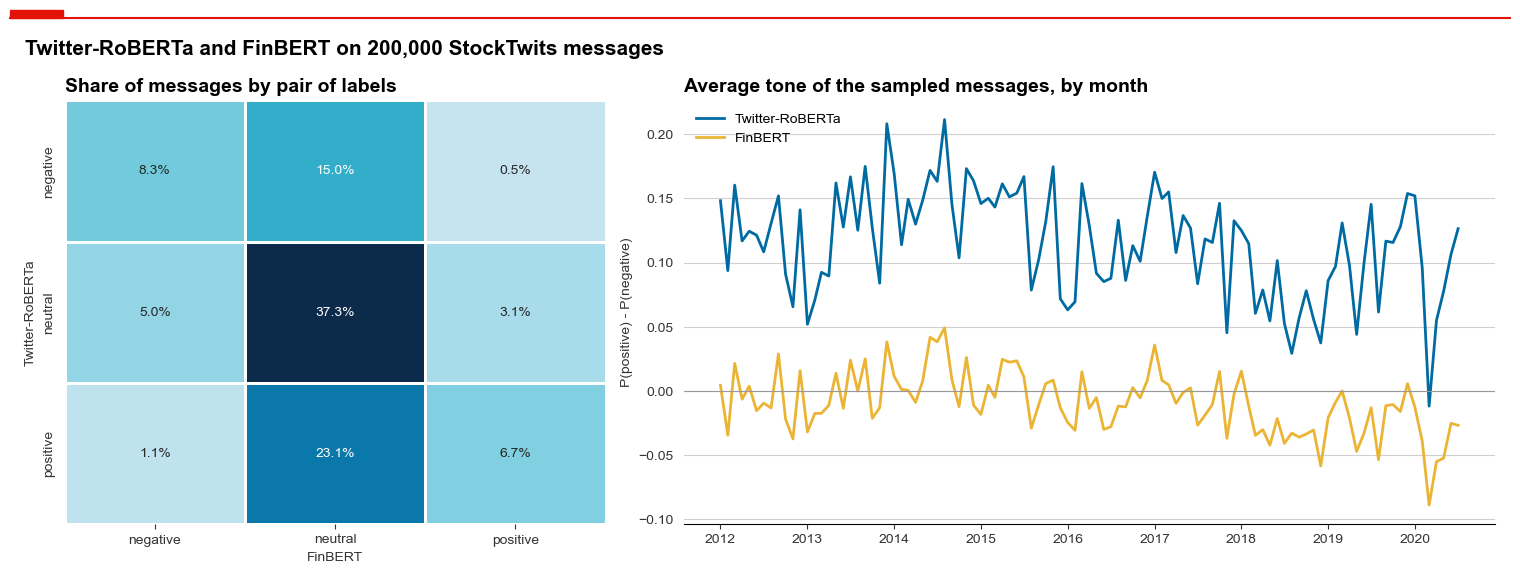

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1, 1.5]})

sns.heatmap(agreement, annot=True, fmt=".1%", cmap=ECONOMIST_BLUES, cbar=False, linewidths=1, ax=axes[0])
axes[0].set_xlabel("FinBERT")
axes[0].set_ylabel("Twitter-RoBERTa")
axes[0].set_title("Share of messages by pair of labels")
axes[0].grid(False)

for key, color in [("roberta", ECONOMIST_COLORS[0]), ("finbert", ECONOMIST_COLORS[3])]:
    axes[1].plot(monthly_tone.index.to_timestamp(), monthly_tone[f"{key}_tone"], color=color, lw=2, label=NAMES[key])
axes[1].axhline(0, color="#999999", lw=0.8)
axes[1].set_title("Average tone of the sampled messages, by month")
axes[1].set_ylabel("P(positive) - P(negative)")
axes[1].grid(False, axis="x")
axes[1].legend(loc="upper left")

fig.suptitle("Twitter-RoBERTa and FinBERT on 200,000 StockTwits messages", x=0.01, ha="left", fontsize=15, fontweight="bold")
show()

**Comments – 3.3**

- **They disagree on half of the messages, and systematically** ($\kappa$ = 0.19, "slight" agreement; Landis and Koch, 1977). FinBERT calls 75% of the messages neutral, Twitter-RoBERTa 45%, so most disagreements are Twitter-RoBERTa positive (23.1% of all messages) or negative (15.0%) against FinBERT neutral. Opposite labels are rare (1.6%). Twitter-RoBERTa is optimistic on average (tone +0.10), FinBERT slightly pessimistic (−0.02).
- **Over time they agree much more:** the tones of single messages correlate at 0.53, their monthly averages at 0.88. Both register the same swings, such as the collapse of March 2020, because aggregation averages out the label noise.
- **Does it make sense that they differ? Yes, as 3.1 suggests:** most posts are no news for an investor, hence FinBERT's "neutral", while Twitter-RoBERTa reads the author's mood, which is not always a view on the stock. Choosing a model means choosing a definition of sentiment. Task 3.4 and 3.5 test both against human judgement and against prices.

### 3.4 Performance on human-labelled finance tweets
Agreement does not tell which model is right, so we measure accuracy on two public sets of finance tweets labelled by people (MIT licence, Hugging Face), on which neither model was trained:
- **Twitter Financial News** (`zeroshot/twitter-financial-news-sentiment`, validation split): 2,388 tweets, mostly news headlines, labelled bearish, bullish or neutral. As 65.6% are neutral, always answering "neutral" already scores 65.6%, so the main metric is the macro F1 score, which weights the three classes equally.
- **FiQA-2018 microblogs** (`TheFinAI/fiqa-sentiment-classification`, posts only): 675 StockTwits and Twitter posts scored from −1 to +1 by finance experts (Maia et al., 2018). Only 4% of the scores are near zero, so we test the direction and the rank correlation between tone and score.

In [49]:
HEADERS = {"User-Agent": "Mozilla/5.0 (Bocconi 20598 PC Lab, academic use)"}


def get_json(url, params, attempts=4):
    '''GET a JSON reply, retrying a few times: the Hugging Face API sometimes answers with an error page.'''
    for attempt in range(attempts):
        reply = requests.get(url, params=params, headers=HEADERS, timeout=60)
        if reply.ok and reply.headers.get("content-type", "").startswith("application/json"):
            return reply.json()
        time.sleep(2 ** attempt)
    reply.raise_for_status()
    raise ValueError(f"No JSON from {url}")


def load_benchmarks(news_cache="benchmark_news.csv", fiqa_cache="benchmark_fiqa.csv"):
    '''The two human-labelled benchmarks, downloaded once from Hugging Face and cached on disk.'''
    if not os.path.exists(news_cache):
        url = "https://huggingface.co/datasets/zeroshot/twitter-financial-news-sentiment/resolve/main/sent_valid.csv"
        news = pd.read_csv(io.StringIO(requests.get(url, headers=HEADERS, timeout=60).text))
        news["label"] = news["label"].map({0: "negative", 1: "positive", 2: "neutral"})     # bearish, bullish, neutral
        news.to_csv(news_cache, index=False)

    if not os.path.exists(fiqa_cache):
        rows, api = [], "https://datasets-server.huggingface.co/rows"
        for split in ["train", "valid", "test"]:
            offset, total = 0, 1
            while offset < total:                                                      # the API returns 100 rows per call
                reply = get_json(api, {"dataset": "TheFinAI/fiqa-sentiment-classification", "config": "default",
                                       "split": split, "offset": offset, "length": 100})
                rows += [item["row"] for item in reply["rows"]]
                offset, total = offset + 100, reply["num_rows_total"]
        fiqa = pd.DataFrame(rows).query("type == 'post'")[["sentence", "target", "score"]].rename(columns={"sentence": "text"})
        fiqa.to_csv(fiqa_cache, index=False)

    return pd.read_csv(news_cache), pd.read_csv(fiqa_cache)


def add_scores(frame):
    '''Scores and labels of both models for a benchmark.'''
    scores = [score_sentiment(model_text(frame["text"]), name).add_prefix(f"{key}_") for key, name in MODELS.items()]
    return add_labels(pd.concat([frame] + scores, axis=1))


news, fiqa = load_benchmarks()
news, fiqa = add_scores(news), add_scores(fiqa)
print(f"Twitter Financial News: {len(news):,} tweets {news['label'].value_counts(normalize=True).round(3).to_dict()}")
print(f"FiQA-2018 posts       : {len(fiqa):,} posts, {(fiqa['score'] > 0).mean():.1%} bullish, {(1- (fiqa['score'] > 0).mean()):.1%} bearish")

Twitter Financial News: 2,388 tweets {'neutral': 0.656, 'positive': 0.199, 'negative': 0.145}
FiQA-2018 posts       : 675 posts, 65.2% bullish, 34.8% bearish


In [ ]:
def benchmark_table(news, fiqa):
    '''Accuracy, macro F1 and recall per class on the news tweets. Direction and ranking on the FiQA posts.'''
    predictions = {NAMES[key]: (news[f"{key}_label"].astype(str), fiqa[f"{key}_tone"]) for key in MODELS}
    predictions["Majority class"] = (pd.Series("neutral", index=news.index), pd.Series(1.0, index=fiqa.index))
    rows = {}

    for model, (labels, tone) in predictions.items():
        f1 = []
        for label in LABELS:
            hits = ((labels == label) & (news["label"] == label)).sum()
            precision, recall = hits / max((labels == label).sum(), 1), hits / (news["label"] == label).sum()
            f1.append(2 * precision * recall / (precision + recall) if hits else 0.0)
        rows[model] = {"news: accuracy": (labels == news["label"]).mean(), "news: macro F1": np.mean(f1),
                       **{f"news: recall {label}": (labels[news["label"] == label] == label).mean() for label in LABELS},
                       "FiQA: direction accuracy": ((tone > 0) == (fiqa["score"] > 0)).mean(),
                       "FiQA: rank correlation": stats.spearmanr(tone, fiqa["score"])[0] if tone.nunique() > 1 else np.nan}

    return pd.DataFrame(rows).T


def mcnemar_p(right_a, right_b):
    '''p-value of McNemar's test that two classifiers are equally accurate on the same items.'''
    return mcnemar(pd.crosstab(right_a, right_b), exact=False).pvalue


news_right = [news[f"{key}_label"].astype(str) == news["label"] for key in MODELS]
fiqa_right = [(fiqa[f"{key}_tone"] > 0) == (fiqa["score"] > 0) for key in MODELS]
print(f"McNemar test of equal accuracy: news p = {mcnemar_p(*news_right):.3f}, FiQA direction p = {mcnemar_p(*fiqa_right):.3f}")
benchmark_table(news, fiqa)

McNemar test of equal accuracy: news p = 0.307, FiQA direction p = 0.004


,news: accuracy,news: macro F1,news: recall negative,news: recall neutral,news: recall positive,FiQA: direction accuracy,FiQA: rank correlation
Twitter-RoBERTa,0.7044,0.6085,0.4841,0.8269,0.4611,0.8148,0.5898
FinBERT,0.7165,0.6577,0.7406,0.7497,0.5895,0.7630,0.5099
Majority class,0.6558,0.2640,0.0000,1.0000,0.0000,0.6519,NaN


**Comments – 3.4**

- **On news, FinBERT is better** (macro F1 0.66 against 0.61), above all on bearish tweets: it finds 74% of them, Twitter-RoBERTa 48%. A downgrade or a profit warning is bad news without sounding upset, which only the finance-trained model sees. Both models are only a few points above always answering "neutral", and FinBERT's accuracy lead (71.7% against 70.4%) is not significant (McNemar $p = 0.31$).
- **On StockTwits posts, Twitter-RoBERTa is better:** it gets 81.5% of the directions right against 76.3% (McNemar $p = 0.004$) and ranks the posts closer to the experts (0.59 against 0.51).
- **Each model is best on the text it was trained on.** Our data are posts, so the second benchmark is the relevant one, though 675 posts are a small test.

### 3.5 Does the tone move with prices?
A financial sentiment measure should at least co-move with its stock. For the four stocks with a complete file of their own (Apple, Amazon, Netflix, Tesla), we correlate the weekly (Saturday to Friday) average tone of the sampled messages naming only that stock with its return in the previous, same and next week (Friday closes, prices of PC Lab #2). Weeks with fewer than 10 sampled messages are dropped.

In [ ]:
BIG_FOUR = ["AAPL", "AMZN", "NFLX", "TSLA"]


def load_prices(path=PRICE_FILE):
    '''Daily closes of today's S&P 500 constituents from PC Lab #2, adjusted for splits and dividends. One column per company.'''
    prices = pd.read_csv(path, parse_dates=["Date"]).set_index("Date").sort_index()
    prices = prices.drop(columns=["GOOG", "FOX", "NWS"])                 # second share classes of Alphabet, Fox, News Corp
    prices.columns = [to_company(ticker) for ticker in prices.columns]  # BRK-B -> BRK.B
    return prices


def weekly_tone(sample, key, tickers, min_messages=10):
    '''Average tone per week (Saturday-Friday) of the sampled messages that name only one of the tickers.'''
    single = sample[sample["n_tickers"] == 1].assign(ticker=lambda d: d["tickers"].str[0])
    single = single[single["ticker"].isin(tickers)]
    week = single["datetime"].dt.tz_localize(None).dt.to_period("W-FRI")
    grouped = single.groupby(["ticker", week])[f"{key}_tone"]
    return grouped.mean().where(grouped.size() >= min_messages).unstack(0)


prices = load_prices()
weekly_returns = prices[BIG_FOUR].resample("W-FRI").last().pct_change().to_period("W-FRI")

rows = []
for key in MODELS:
    tone = weekly_tone(sample, key, BIG_FOUR).reindex(weekly_returns.index)
    for ticker in BIG_FOUR:
        valid = tone[ticker].notna() & weekly_returns[ticker].notna()
        rows.append({"model": NAMES[key], "stock": ticker, "weeks": int(valid.sum()),
                     "previous week": tone[ticker].corr(weekly_returns[ticker].shift(1)),
                     "same week": tone[ticker].corr(weekly_returns[ticker]),
                     "next week": tone[ticker].corr(weekly_returns[ticker].shift(-1))})

price_check = pd.DataFrame(rows)
print("Correlation of the weekly tone with the stock's return in the previous, same and next week")
price_check.pivot(index="stock", columns="model", values=["previous week", "same week", "next week"]).round(3)

Correlation of the weekly tone with the stock's return in the previous, same and next week


previous week                 same week                 next week  \
model       FinBERT Twitter-RoBERTa   FinBERT Twitter-RoBERTa   FinBERT   
stock                                                                     
AAPL         0.1380          0.1270    0.3140          0.2950   -0.0430   
AMZN         0.1280          0.0550    0.2620          0.3180   -0.0150   
NFLX        -0.0050         -0.0200    0.2250          0.2480    0.0750   
TSLA         0.0940          0.1420    0.2860          0.3350   -0.0550   

                       
model Twitter-RoBERTa  
stock                  
AAPL          -0.0540  
AMZN           0.0040  
NFLX           0.1010  
TSLA           0.0330

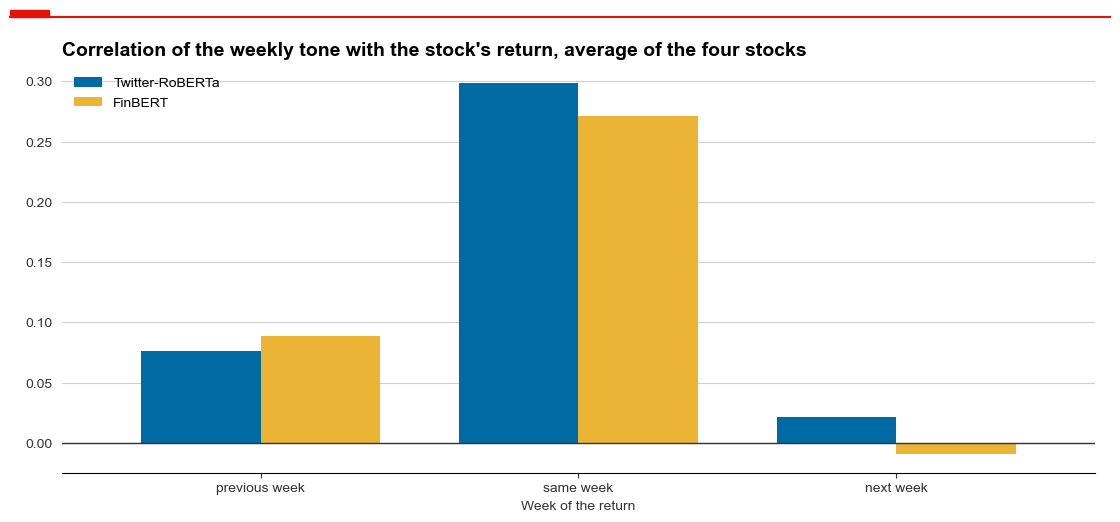

In [29]:
timing = price_check.groupby("model")[["previous week", "same week", "next week"]].mean().loc[[NAMES[key] for key in MODELS]].T

ax = timing.plot.bar(figsize=(11, 5), rot=0, width=0.75, color=[ECONOMIST_COLORS[0], ECONOMIST_COLORS[3]])
ax.axhline(0, color="#333333", lw=1)
ax.set_title("Correlation of the weekly tone with the stock's return, average of the four stocks")
ax.set_xlabel("Week of the return")
ax.grid(False, axis="x")
ax.legend(loc="upper left")
show()

**Comments – 3.5**

- **Both tones co-move with prices:** 0.22 to 0.34 with the same week's return, on average 0.30 for Twitter-RoBERTa (higher for Amazon, Netflix and Tesla) and 0.27 for FinBERT (higher for Apple).
- **Sentiment follows prices. It does not lead them.** The correlation with the previous week's return is still positive (about 0.08), with the next week's it is zero: investors comment on what the price has done, a first hint for Task #4.
- **In line with semistrong form of market efficiency:** the public tone of StockTwits messages does not predict next week's return, but incorporates public available informations. Caveat: with four stocks and a sampled tone the test has limited power.

### 3.6 Where the models disagree
Two randomly drawn messages for each of the four most frequent kinds of disagreement:

In [30]:
pairs = agreement.stack().loc[lambda s: [a != b for a, b in s.index]].nlargest(4).index

disagreements = pd.concat([
    sample[(sample["roberta_label"] == a) & (sample["finbert_label"] == b) & sample["words"].between(6, 30)]
    .sample(2, random_state=SEED)
    for a, b in pairs])
disagreements[["text", "roberta_label", "finbert_label"]].rename(
    columns={"roberta_label": "Twitter-RoBERTa", "finbert_label": "FinBERT"}).set_index("text")

,Twitter-RoBERTa,FinBERT
text,,
$NFLX flagging or double top on the 5 min!!! important next few mins here for day traders....,positive,neutral
$AAPL Jobs focused on functionality. Apple was known for its ease of use & its unsurpassed quality—without gimmicks. \n\nThat has changed.,positive,neutral
$TSLA glad musk is leaving California... f**k California. glad to be moving away soon.,negative,neutral
"@MusicMaker With the absurd negativity you share, I'm surprised you would buy $AAPL at any price.",negative,neutral
$NFLX i am!! I lost money on the runup yesterday and calling sell my calls for a profit,neutral,negative
"$TSLA Weak close below $160, Longs better start to be concerned imo!",neutral,negative
$NFLX Bears got nothing. Is this gonna run to $600?? Up 40 points from last night but think I am gonna keep holding for now.,neutral,positive
"RT @agwarner $AAPL Weekly 360 calls traded over 30K yesterday, open interest increased by only 3K",neutral,positive


### 3.7 Which model we use, and why

We use **Twitter-RoBERTa**:
1. **It is more accurate on posts like ours** (3.4).
2. **Its tone moves more closely with prices** (3.5).
3. **It reads the platform's language.** FinBERT turns every emoji into `[UNK]`, although 11% of the 2020 messages contain one and the rocket is among the most positive words (3.8), and it calls three quarters of the messages neutral, discarding most of the signal.

What we give up: FinBERT is better on headlines, and in 3.6 it reads market vocabulary that Twitter-RoBERTa misses ("weak close below \$160", "bears got nothing"), while Twitter-RoBERTa sometimes reacts to emotions that are not about the stock ("glad Musk is leaving California"). Fine-tuning either model on labelled StockTwits messages would be the next step. The choice only affects the sentiment split of 4.1. The attention measure of 4.2 to 4.5 counts messages.

### 3.8 Word clouds by sentiment (Task #2)
The Task #2 pipeline on the sampled messages, split by the Twitter-RoBERTa label. Sized by raw frequency, both clouds would show the same words (*stock, market, go, up*). We size words by *keyness* instead: the frequency in the class times the log of how much more often the word appears there than in the other class. A word is large only if it is frequent *and* typical of the class. Words used fewer than 50 times are left out.

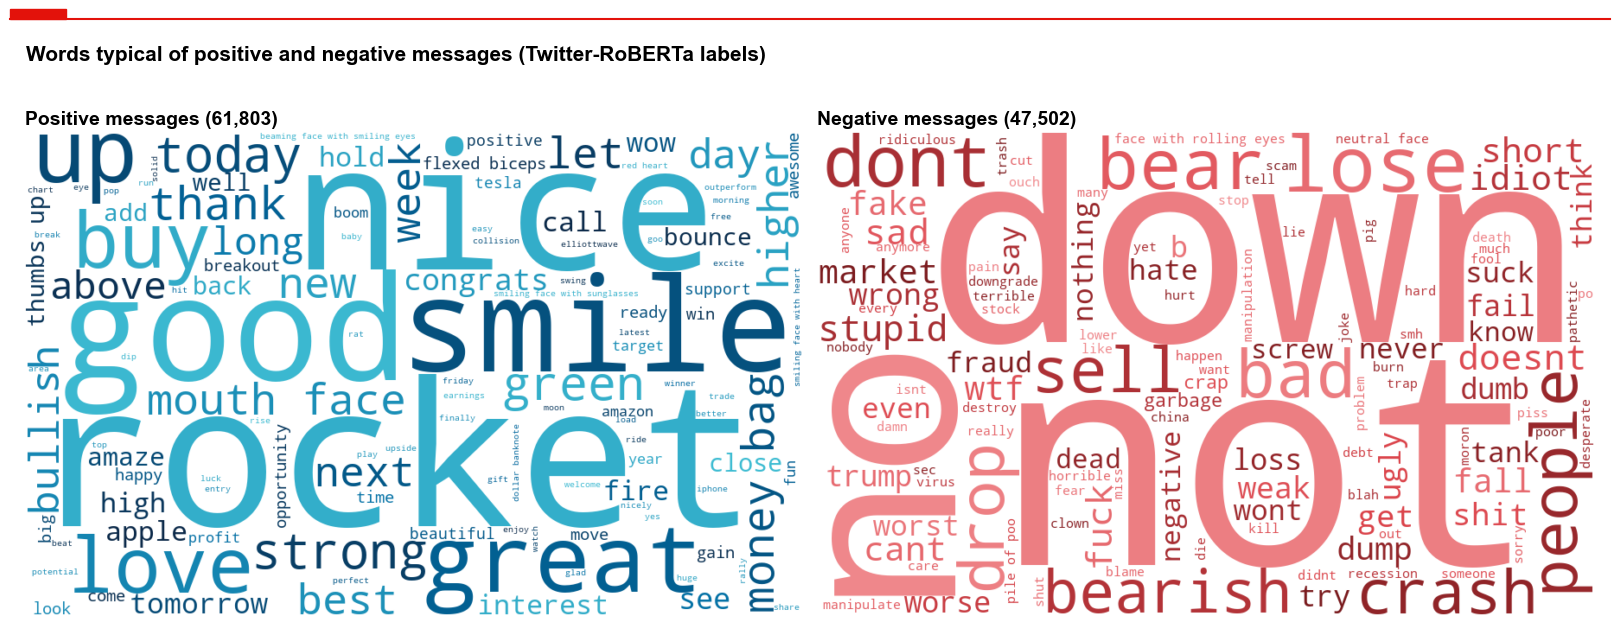

In [31]:
CHOSEN = "roberta"                  # see 3.7


def keyness(counts, other, min_count=50):
    '''Frequency of each word in one class times the log ratio of its rates in that class and in the other one.'''
    total, total_other = sum(counts.values()), sum(other.values())
    scores = {}
    for word, n in counts.items():
        ratio = (n / total) / ((other.get(word, 0) + 1) / total_other)
        if n >= min_count and ratio > 1:
            scores[word] = n * np.log(ratio)
    return scores


words = clean_text(sample["text"]).map(tokenize)
counts = {label: Counter(word for message in words[sample[f"{CHOSEN}_label"] == label] for word in message)
          for label in ["positive", "negative"]}

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, (label, other, colors) in zip(axes, [("positive", "negative", ["#3EBCD2", "#006BA2", "#0C2A4A"]),
                                             ("negative", "positive", ["#F08A8E", "#DB444B", "#7A1B1E"])]):
    scores = {word.replace("_", " "): score for word, score in keyness(counts[label], counts[other]).items()}   # emoji names
    cloud = WordCloud(width=900, height=560, background_color="white", max_words=120, random_state=SEED,
                      colormap=LinearSegmentedColormap.from_list(label, colors)).generate_from_frequencies(scores)
    ax.imshow(cloud, interpolation="bilinear")
    ax.set_title(f"{label.capitalize()} messages ({(sample[f'{CHOSEN}_label'] == label).sum():,})")
    ax.axis("off")

fig.suptitle(f"Words typical of positive and negative messages ({NAMES[CHOSEN]} labels)", x=0.01, ha="left", fontsize=15, fontweight="bold")
show()

**Comments – 3.8**

- **The labels make sense.** Positive messages celebrate gains (*rocket, nice, great, congrats, bullish, strong, green, breakout*) with the platform's emojis (money bag, flexed biceps, fire, thumbs up). Negative ones are about losses (*down, lose, crash, bearish, sell, dump, weak*), insults and accusations (*stupid, idiot, fraud, fake, scam, manipulate*), and the politics and pandemic of 2019-2020 (*trump, china, virus, recession*).
- Option vocabulary splits the same way (*short* negative, *call* positive), although Twitter-RoBERTa was not trained on financial text.
- The largest negative words are negations and directions (*not, no, down, dont*). A standard stopword list would have removed the first three (Task #2).

## Task #4 – Measuring media attention
Is Twitter attention a new factor? We count the messages about each stock (4.1), build a monthly attention measure $g_{i,t}$ (4.2), sort the stocks into ten portfolios on $g$ and relate it to returns in the same and the following month (4.3), test the spread against the Fama-French five factors (4.4) and plot the FF5 errors against $g$ (4.5, optional).

### 4.1 Tweets per stock and year
The ticker list is the one scraped from Wikipedia in PC Lab #2, i.e. the columns of the price file saved there (500 companies after merging share classes). A message counts once for every company it names. The sentiment split applies each stock-year's label shares in the scored sample (3.2) to its number of messages. Following Antweiler and Frank (2004), **bullishness** is $\ln\frac{1 + N^{pos}}{1 + N^{neg}}$ and **disagreement** $\sqrt{1 - \left(\frac{N^{pos} - N^{neg}}{N^{pos} + N^{neg}}\right)^2}$, 0 when all opinionated messages agree and 1 when they split evenly. Both need at least 100 scored messages in the year.

In [32]:
SP500 = prices.columns                                                   # the PC Lab #2 list, one ticker per company

mentions = corpus[["message_id", "datetime", "tickers"]].explode("tickers").rename(columns={"tickers": "ticker"})
mentions = mentions[mentions["ticker"].isin(SP500)]
mentions["year"] = mentions["datetime"].dt.year
mentions["month"] = mentions["datetime"].dt.tz_localize(None).dt.to_period("M")

print(f"{len(mentions):,} mentions of {mentions['ticker'].nunique()} of the {len(SP500)} companies, "
      f"in {mentions['message_id'].nunique() / len(corpus):.0%} of the clean messages")


def attention_by_year(mentions, sample, year, key=CHOSEN, min_scored=100):
    '''Messages per company in one year, the estimated split by sentiment, bullishness and disagreement.'''
    scored = sample.loc[sample["datetime"].dt.year == year, ["tickers", f"{key}_label"]].explode("tickers")
    shares = scored.groupby("tickers")[f"{key}_label"].value_counts(normalize=True).unstack().reindex(columns=LABELS, fill_value=0)

    table = mentions[mentions["year"] == year].groupby("ticker").size().rename("messages").to_frame()
    table["scored"] = scored.groupby("tickers").size().reindex(table.index, fill_value=0)
    for label in LABELS:
        table[label] = (table["messages"] * shares[label].reindex(table.index)).where(table["scored"] >= min_scored).round()

    table["bullishness"] = np.log((1 + table["positive"]) / (1 + table["negative"]))
    table["disagreement"] = np.sqrt(1 - ((table["positive"] - table["negative"]) / (table["positive"] + table["negative"])) ** 2)
    return table.sort_values("messages", ascending=False)


attention_2019 = attention_by_year(mentions, sample, 2019)
print(f"2019, the last complete year: {len(attention_2019)} companies named, the top 10 receive {attention_2019['messages'].head(10).sum() / attention_2019['messages'].sum():.0%} of the mentions")
attention_2019.head(15).style.format({"messages": "{:,.0f}", "scored": "{:,.0f}", "negative": "{:,.0f}", "neutral": "{:,.0f}",
                                      "positive": "{:,.0f}", "bullishness": "{:.2f}", "disagreement": "{:.2f}"})

5,250,588 mentions of 480 of the 500 companies, in 88% of the clean messages
2019, the last complete year: 462 companies named, the top 10 receive 89% of the mentions


,messages,scored,negative,neutral,positive,bullishness,disagreement
ticker,,,,,,,
TSLA,"341,673","13,597","93,051","133,684","114,938",0.21,0.99
AAPL,"164,408","6,476","42,117","70,500","51,790",0.21,0.99
AMZN,"112,583","4,488","25,136","49,945","37,503",0.40,0.98
NFLX,"104,012","4,071","29,050","43,920","31,043",0.07,1.00
DIS,"61,877","2,544","13,888","24,007","23,982",0.55,0.96
META,"25,354",999,"5,837","10,329","9,187",0.45,0.97
GOOGL,"20,196",809,"4,244","8,088","7,864",0.62,0.95
T,"14,816",579,"2,533","7,549","4,734",0.63,0.95
BAC,"12,943",517,"2,253","7,435","3,255",0.37,0.98


In [33]:
# Rankings on alternative measures, among the companies with at least 100 scored messages in 2019
opinions = attention_2019.dropna()
share_positive = opinions["positive"] / opinions["messages"]
share_negative = opinions["negative"] / opinions["messages"]

rankings = pd.DataFrame({
    "positive attention (share)": [f"{t} {share_positive[t]:.0%}" for t in share_positive.nlargest(10).index],
    "negative attention (share)": [f"{t} {share_negative[t]:.0%}" for t in share_negative.nlargest(10).index],
    "disagreement": [f"{t} {opinions.loc[t, 'disagreement']:.2f}" for t in opinions["disagreement"].nlargest(10).index],
}, index=pd.RangeIndex(1, 11, name="rank"))
print(f"{len(opinions)} companies with at least 100 scored messages in 2019")
display(rankings)

# The ten most discussed companies, year by year (2020: January to July)
top10 = mentions.groupby(["year", "ticker"]).size().groupby(level=0, group_keys=False).nlargest(10)
pd.DataFrame({year: top10.loc[year].index.get_level_values("ticker") for year in range(2012, 2021)}, index=pd.RangeIndex(1, 11, name="rank"))

22 companies with at least 100 scored messages in 2019


,positive attention (share),negative attention (share),disagreement
rank,,,
1,ADBE 39%,BA 31%,MU 1.00
2,GOOGL 39%,MU 30%,BA 1.00
3,DIS 39%,F 28%,NFLX 1.00
4,MSFT 38%,NFLX 28%,F 1.00
5,VZ 37%,TSLA 27%,PG 0.99
6,META 36%,AAPL 26%,AAPL 0.99
7,AMD 36%,META 23%,TSLA 0.99
8,INTC 35%,DIS 22%,BAC 0.98
9,WMT 34%,AMZN 22%,AMZN 0.98


,2012,2013,2014,2015,2016,2017,2018,2019,2020
rank,,,,,,,,,
1,AAPL,AAPL,AAPL,AAPL,AAPL,TSLA,TSLA,TSLA,TSLA
2,NFLX,TSLA,TSLA,NFLX,TSLA,AAPL,AAPL,AAPL,AAPL
3,AMZN,NFLX,NFLX,TSLA,NFLX,AMZN,NFLX,AMZN,AMZN
4,GOOGL,AMZN,AMZN,AMZN,AMZN,NFLX,AMZN,NFLX,DIS
5,BAC,GOOGL,GOOGL,DIS,DIS,GOOGL,DIS,DIS,NFLX
6,TSLA,BAC,META,GOOGL,GOOGL,DIS,GOOGL,META,META
7,META,META,DIS,META,META,META,META,GOOGL,MSFT
8,VZ,DIS,BAC,BAC,BAC,BAC,T,T,GOOGL
9,T,VZ,T,V,T,NVDA,BAC,BAC,BAC


**Comments – 4.1**

- **Attention is extremely concentrated.** The mentions cover 480 of the 500 companies, yet in 2019 the top 10 receive 89% and Tesla twice as many as Apple. The ranking is stable: Apple leads until 2016, Tesla from 2017, and Tesla, Apple, Amazon and Netflix are in every top five since 2017.
- **It partly reflects the collection.** The top places belong to companies with a file of their own: Microsoft and AMD reach the 2019 top 15, and Nvidia, Microsoft and Boeing a yearly top 10, only through messages that also name one of the 25 symbols. A complete stream would probably rank them higher.
- **Positive and negative shares tell a different story.** In 2019 Boeing has the largest share of negative messages (31%), the year of the 737 MAX groundings, ahead of Micron and Ford. Adobe, Alphabet and Disney have the largest positive shares (39%). With 100 to 300 scored messages the shares carry errors of +/- 5 to 10 pp, so only large gaps count.
- **Disagreement is the rule:** from 0.87 (Adobe) to 1.00 (Netflix) among the 15 most discussed companies, and highest for the most discussed. Bulls and bears talk past each other, as Cookson and Niessner (2020) document on the same platform.

### 4.2 A monthly measure of attention
Yearly counts are too coarse for a factor test, so we count the messages per company and month, $N_{i,t}$, from January 2012 to June 2020 (the last complete month). Besides the **level** $\ln(1 + N_{i,t})$ we define **abnormal attention**, the level minus its average over the previous twelve months:
$$g_{i,t} = \ln(1 + N_{i,t}) - \frac{1}{12}\sum_{k=1}^{12}\ln(1 + N_{i,t-k}).$$

We prefer $g$, for three reasons:
1. The level mostly records *which* stock it is: large, familiar technology firms are discussed more, and size and style are already priced by FF5.
2. In this corpus the level also records how a stock was collected: through a file of its own (19 companies) or only when named next to one of the 25 symbols. Comparing a stock with its own past removes this effect as well as the growth of StockTwits.
3. $g$ is the attention *shock* of Barber and Odean (2008) and Da, Engelberg and Gao (2011): unusual discussion, not the usual amount, should move prices.

The universe is the S&P 500 companies with at least 12 messages over the previous twelve months (below that, $g$ jumps between zero and one message). The level is kept for comparison.

**Why message counts and not sentiment?** Sentiment is known only for the 3.9% scored sample (3.2). Of the 19,682 covered stock-months, 69% contain no scored message and only 3.6% contain 30 or more, so a monthly sentiment measure would be noise for all but the few most discussed stocks. Bullishness and disagreement therefore stay at the yearly level of 4.1, and the factor test uses attention, which is counted on all five million messages.

In [34]:
FACTORS = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
HAC_LAGS = 3            # Newey-West lags for about 90 monthly observations, the 4 (T/100)^(2/9) rule


def ols(y, x, hac_lags=0, clusters=None):
    '''
    OLS of y on a constant and x, estimated with statsmodels (as in PC Lab #2).
    hac_lags > 0 returns Newey-West standard errors, clusters returns standard errors clustered by that group.
    '''
    model = sm.OLS(np.asarray(y, dtype=float), sm.add_constant(np.asarray(x, dtype=float)))
    if clusters is not None:
        return model.fit(cov_type="cluster", cov_kwds={"groups": np.asarray(clusters)})
    if hac_lags:
        return model.fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    return model.fit()


def monthly_attention(mentions, companies, start="2012-01", end="2020-06"):
    '''Messages per company and month, and for the covered companies the level ln(1 + N) and abnormal attention g.'''
    counts = (mentions.groupby(["month", "ticker"]).size().unstack(fill_value=0)
              .reindex(index=pd.period_range(start, end, freq="M"), columns=companies, fill_value=0))
    level = np.log1p(counts)
    abnormal = level - level.rolling(12).mean().shift(1)
    covered = counts.rolling(12).sum().shift(1) >= 12                      # at least 12 messages in the previous year
    return counts, level.where(covered), abnormal.where(covered)


def fama_french_5(cache="F-F_Research_Data_5_Factors_2x3.csv"):
    '''Monthly Fama-French five factors and risk-free rate, in decimals, from Ken French's Data Library (cached on disk).'''
    if not os.path.exists(cache):
        url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip"
        archive = zipfile.ZipFile(io.BytesIO(requests.get(url, headers=HEADERS, timeout=60).content))
        with open(cache, "wb") as file:
            file.write(archive.read(archive.namelist()[0]))

    lines = open(cache, encoding="latin-1").read().splitlines()
    start = next(i for i, line in enumerate(lines) if line.startswith(",Mkt-RF"))        # the monthly table comes first,
    end = next(i for i in range(start + 1, len(lines)) if not lines[i].strip())          # the annual one after a blank line
    factors = pd.read_csv(io.StringIO("\n".join(lines[start:end])), index_col=0)
    factors.index = pd.PeriodIndex(factors.index.astype(str), freq="M")
    return factors / 100


counts, level, g = monthly_attention(mentions, SP500)
ff5 = fama_french_5()
monthly_returns = prices.resample("ME").last().pct_change(fill_method=None).to_period("M")
excess = monthly_returns.sub(ff5.loc[monthly_returns.index, "RF"], axis=0)

covered = g.notna().sum(axis=1).loc["2013-01":]
persistence = {name: pd.concat([m.stack(), m.shift(1).stack()], axis=1).corr().iloc[0, 1] for name, m in [("level", level), ("g", g)]}
print(f"Covered companies: {covered.iloc[0]} in {covered.index[0]}, {covered.iloc[-1]} in {covered.index[-1]}, {covered.mean():.0f} on average")
print(f"Correlation with the previous month: level {persistence['level']:.2f}, abnormal attention g {persistence['g']:.2f}")

Covered companies: 128 in 2013-01, 367 in 2020-06, 219 on average
Correlation with the previous month: level 0.90, abnormal attention g 0.33


### 4.3 Ten portfolios sorted on attention
Each month the covered stocks are sorted into ten equally weighted portfolios on $g$, from 1 (attention furthest below normal) to 10 (furthest above), 13 to 37 stocks each. The file of PC Lab #2 has no market capitalisations for value weights. Returns are in excess of the risk-free rate. Two timings:
- **same month**, $g_{i,t}$ against $r_{i,t}$: the correlation the slides ask about, not tradable since $g_{i,t}$ is known only at the end of month $t$
- **previous month**, $g_{i,t-1}$ against $r_{i,t}$: the lag of media attention, a portfolio formed at the end of month $t-1$ and held during month $t$.

In [35]:
def shift_months(signal, lag):
    '''The signal of month t - lag in the row of month t, extended by lag months at the end.'''
    return signal.reindex(pd.period_range(signal.index[0], signal.index[-1] + lag, freq="M")).shift(lag)


def attention_portfolios(signal, excess, lag):
    '''Monthly excess returns of ten equally weighted portfolios sorted on the signal of the same (lag 0) or previous month (lag 1).'''
    signal = shift_months(signal, lag)
    rows = {}

    for month in signal.index:
        score = signal.loc[month].dropna()
        score = score[excess.loc[month, score.index].notna()]              # stocks with a return this month
        if len(score) >= 50:
            decile = pd.qcut(score.rank(method="first"), 10, labels=range(1, 11))
            rows[month] = excess.loc[month, score.index].groupby(decile, observed=True).mean()

    portfolios = pd.DataFrame(rows).T
    portfolios["10 - 1"] = portfolios[10] - portfolios[1]
    return portfolios


def mean_t(series):
    '''Average monthly return and its Newey-West t-statistic.'''
    fit = ols(series, np.empty((len(series), 0)), hac_lags=HAC_LAGS)
    return pd.Series({"return": fit.params[0], "t": fit.tvalues[0]})


def alpha_t(series):
    '''FF5 alpha of a monthly return series and its Newey-West t-statistic.'''
    fit = ols(series, ff5.loc[series.index, FACTORS], hac_lags=HAC_LAGS)
    return pd.Series({"FF5 alpha": fit.params[0], "t(alpha)": fit.tvalues[0]})


portfolios = {(measure, timing): attention_portfolios(signal, excess, lag)
              for measure, signal in [("g", g), ("level", level)]
              for timing, lag in [("same month", 0), ("previous month", 1)]}

same, lagged = portfolios[("g", "same month")], portfolios[("g", "previous month")]
print(f"Returns {same.index[0]} to {same.index[-1]} with g of the same month, {lagged.index[0]} to {lagged.index[-1]} "
      f"with g of the previous month ({len(same)} months each)")

decile_table = pd.concat([same.apply(mean_t).T.add_prefix("same month: "),
                          lagged.apply(mean_t).T.add_prefix("previous month: "),
                          lagged.apply(alpha_t).T.add_prefix("previous month: ")], axis=1)
decile_table.style.format({column: "{:.2f}" if column.split(": ")[1].startswith("t") else "{:.2%}" for column in decile_table.columns})

Returns 2013-01 to 2020-06 with g of the same month, 2013-02 to 2020-07 with g of the previous month (90 months each)


,same month: return,same month: t,previous month: return,previous month: t,previous month: FF5 alpha,previous month: t(alpha)
1,0.53%,1.72,1.73%,4.42,0.65%,3.76
2,0.91%,2.40,1.24%,3.18,0.27%,1.67
3,0.89%,2.29,0.98%,2.48,-0.28%,-1.74
4,1.17%,3.12,1.45%,3.34,0.26%,1.73
5,1.24%,3.78,1.37%,3.73,0.28%,1.50
6,1.27%,3.28,1.17%,3.21,0.02%,0.10
7,1.64%,3.90,1.15%,3.18,0.05%,0.32
8,1.41%,3.83,0.99%,2.43,-0.14%,-0.99
9,1.68%,4.05,1.39%,3.73,0.24%,1.45
10,2.53%,4.57,1.65%,4.03,0.53%,2.77


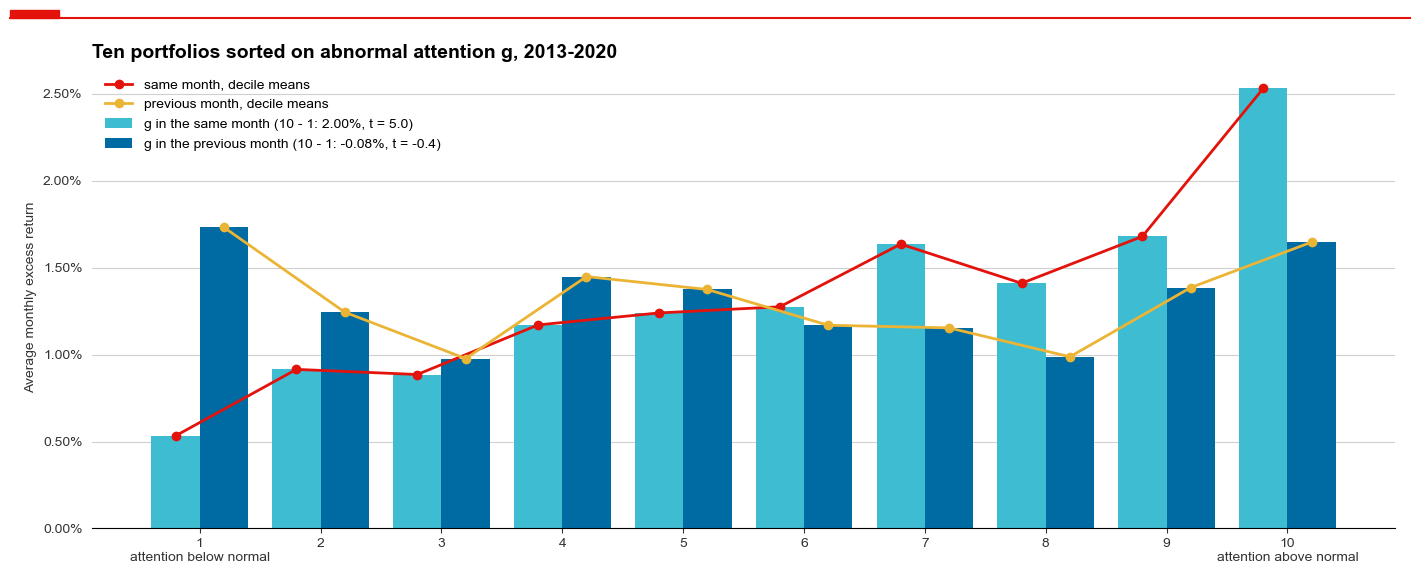

In [52]:
fig, ax = plt.subplots(figsize=(14, 5.5))
positions = np.arange(10)

ax.bar(positions - 0.2, decile_table["same month: return"].iloc[:10], width=0.4, color=ECONOMIST_COLORS[1],
       label=f"g in the same month (10 - 1: {decile_table.loc['10 - 1', 'same month: return']:.2%}, t = {decile_table.loc['10 - 1', 'same month: t']:.1f})")
ax.bar(positions + 0.2, decile_table["previous month: return"].iloc[:10], width=0.4, color=ECONOMIST_COLORS[0],
       label=f"g in the previous month (10 - 1: {decile_table.loc['10 - 1', 'previous month: return']:.2%}, t = {decile_table.loc['10 - 1', 'previous month: t']:.1f})")
ax.set_xticks(positions, ["1\nattention below normal"] + [str(d) for d in range(2, 10)] + ["10\nattention above normal"])
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel("Average monthly excess return")
ax.set_title("Ten portfolios sorted on abnormal attention g, 2013-2020")
ax.grid(False, axis="x")
for column, x, color, label in [("same month: return", np.subtract(positions, 0.2), ECONOMIST_RED, "same month, decile means"),
                                ("previous month: return", np.add(positions, 0.2), ECONOMIST_COLORS[3], "previous month, decile means")]:
    ax.plot(x, decile_table[column].iloc[:10], color=color, marker="o", lw=2, label=label)
ax.legend(loc="upper left")
show()

**Correlation.** The direct measure is the cross-sectional rank correlation between attention and returns, computed each month and averaged (Fama-MacBeth, $t$ = mean / SE). The correlation with the absolute return shows how much attention follows the size of a move rather than its sign.

In [37]:
def monthly_correlations(signal, values, lag):
    '''Rank correlation across stocks between the signal (same or previous month) and the values, for each month.'''
    signal = shift_months(signal, lag)
    return pd.Series({month: signal.loc[month].corr(values.loc[month], method="spearman")
                      for month in signal.index if signal.loc[month].notna().sum() >= 50})


rows = {}
for name, signal in [("abnormal attention g", g), ("attention level", level)]:
    for timing, lag in [("same month", 0), ("previous month", 1)]:
        with_return = monthly_correlations(signal, excess, lag)
        rows[f"{name}, {timing}"] = {"corr. with return": with_return.mean(),
                                     "t-statistic": with_return.mean() / with_return.sem(),
                                     "months positive": (with_return > 0).mean(),
                                     "corr. with |return|": monthly_correlations(signal, excess.abs(), lag).mean()}

pd.DataFrame(rows).T

,corr. with return,t-statistic,months positive,corr. with |return|
"abnormal attention g, same month",0.0606,7.5692,0.8222,0.1169
"abnormal attention g, previous month",-0.0115,-1.2694,0.4444,-0.0092
"attention level, same month",0.0343,3.7985,0.7111,0.0463
"attention level, previous month",-0.0022,-0.2500,0.5444,-0.0123


**Comments – 4.3**

- **In the same month, attention and returns are strongly correlated.** Returns rise almost monotonically from 0.53% a month (portfolio 1) to 2.53% (portfolio 10), and the rank correlation is positive in 82% of the months ($t = 7.6$).
- **More with the size of the move than with its sign:** the rank correlation with the absolute return is twice as high (0.117 against 0.061). Attention jumps when a stock moves, a little more when it rises.
- **Last month's attention explains nothing.** The ten portfolios earn 0.98% to 1.73% a month in no order, the 10 − 1 spread is −0.08% ($t = −0.4$), and the rank correlation is positive in only 44% of the months: what attention says about a stock is in its price by the end of the month. The level behaves the same way, more weakly. This is in line with the semistrong form of market efficiency: public information, here StockTwits messages, cannot be used to predict next month's return, although the thin coverage outside the 25 collected symbols limits the power of the test.
- **One pattern stands out:** both extreme portfolios beat the middle ones the following month (FF5 alphas of 0.65%, $t = 3.8$, and 0.53%, $t = 2.8$). A U shape is not the monotonic spread a factor needs, but it could mean that unusual attention in either direction is priced. 4.4 tests it.

### 4.4 Could Twitter attention be a factor?
A factor candidate needs a return spread that is known before the month starts and that existing factors do not explain. We regress each 10 − 1 spread on the five factors:
$$r^{10-1}_t = \alpha + \beta\,\text{MKT}_t + s\,\text{SMB}_t + h\,\text{HML}_t + r\,\text{RMW}_t + c\,\text{CMA}_t + \varepsilon_t .$$

In [38]:
rows = {}
for (measure, timing), spread in ((key, p["10 - 1"]) for key, p in portfolios.items()):
    fit = ols(spread, ff5.loc[spread.index, FACTORS], hac_lags=HAC_LAGS)
    rows[f"{measure}, {timing}"] = {"mean": spread.mean(), "t(mean)": mean_t(spread)["t"],
                                    "Sharpe p.a.": spread.mean() / spread.std() * np.sqrt(12),
                                    "FF5 alpha": fit.params[0], "t(alpha)": fit.tvalues[0],
                                    **dict(zip(FACTORS, fit.params[1:])), "R2": fit.rsquared}

spread_table = pd.DataFrame(rows).T
spread_table.style.format({"mean": "{:.2%}", "FF5 alpha": "{:.2%}", **{c: "{:.2f}" for c in ["t(mean)", "Sharpe p.a.", "t(alpha)", "R2"] + FACTORS}})

,mean,t(mean),Sharpe p.a.,FF5 alpha,t(alpha),Mkt-RF,SMB,HML,RMW,CMA,R2
"g, same month",2.00%,5.02,1.80,1.81%,4.54,0.23,0.22,0.23,0.39,-0.39,0.19
"g, previous month",-0.08%,-0.39,-0.11,-0.12%,-0.52,0.06,0.08,0.05,-0.04,-0.12,0.03
"level, same month",1.36%,5.30,1.83,1.09%,3.81,0.18,-0.37,0.22,-0.26,-0.64,0.23
"level, previous month",0.47%,1.69,0.62,0.21%,0.68,0.12,-0.47,0.11,-0.43,-0.58,0.25


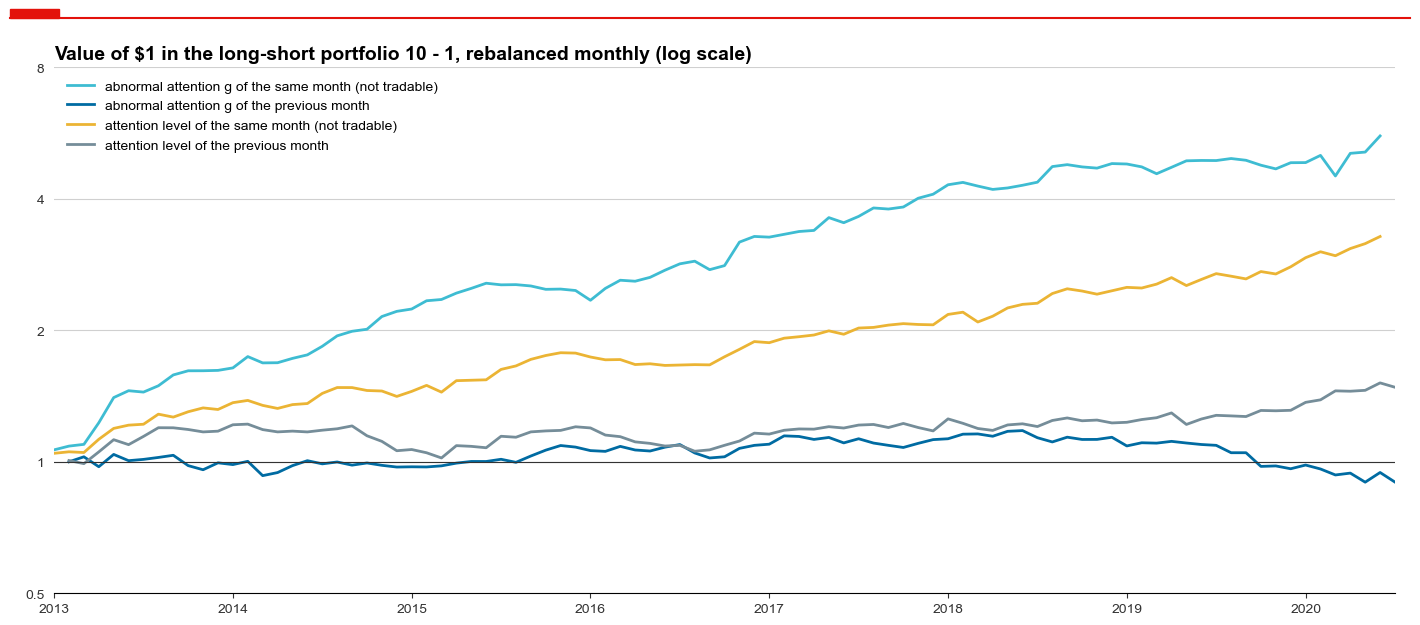

In [39]:
names = {"g": "abnormal attention g", "level": "attention level"}
growth = pd.DataFrame({f"{names[measure]} of the {timing}" + (" (not tradable)" if timing == "same month" else ""): (1 + p["10 - 1"]).cumprod()
                       for (measure, timing), p in portfolios.items()})

ax = growth.plot(figsize=(14, 6), color=[ECONOMIST_COLORS[1], ECONOMIST_COLORS[0], ECONOMIST_COLORS[3], ECONOMIST_COLORS[7]], lw=2)
ax.set_yscale("log")
ax.set_yticks([0.5, 1, 2, 4, 8], labels=["0.5", "1", "2", "4", "8"])
ax.minorticks_off()
ax.axhline(1, color="#333333", lw=0.8)
ax.set_title("Value of $1 in the long-short portfolio 10 - 1, rebalanced monthly (log scale)")
ax.set_xlabel("")
ax.grid(False, axis="x")
ax.legend(loc="upper left", fontsize=10)
show()

**Extreme attention.** The U-shape of 4.3 suggests a different candidate: unusual attention in either direction. We test it twice: as the spread between the extreme deciles (1 and 10) and the middle ones (4 to 7) of the previous-month sort, and as a factor-style sort on the distance of last month's $g$ from the month's median, $|g_{i,t-1} - \text{median}_t(g)|$. Both ideas come from the data we test them on, so we also split the sample into two halves: a real effect should appear in both.

In [40]:
def extremes_minus_middle(portfolios):
    '''Average of the extreme deciles (1 and 10) minus the average of the middle ones (4 to 7).'''
    return (portfolios[1] + portfolios[10]) / 2 - portfolios[[4, 5, 6, 7]].mean(axis=1)


surprise = g.sub(g.median(axis=1), axis=0).abs()        # distance from the month's typical g, in either direction
candidates = {"extremes - middle of g": extremes_minus_middle(portfolios[("g", "previous month")]),
              "|g - median|, 10 - 1": attention_portfolios(surprise, excess, lag=1)["10 - 1"]}

rows = {}
for name, spread in candidates.items():
    for start, end in [("2013", "2020"), ("2013", "2016"), ("2017", "2020")]:
        rows[(name, f"{start}-{end}")] = pd.concat([mean_t(spread.loc[start:end]), alpha_t(spread.loc[start:end])])

# How much is said about the stocks in each decile of g: messages per month over the previous year
pooled = pd.DataFrame({"g": g.loc["2013-01":].stack(), "messages": counts.rolling(12).mean().shift(1).stack()}).dropna()
pooled["decile"] = pooled.groupby(level=0)["g"].transform(lambda s: pd.qcut(s.rank(method="first"), 10, labels=False) + 1)
print("Median messages per month over the previous year, by decile of g:",
      ", ".join(f"{d}: {m:.1f}" for d, m in pooled.groupby("decile")["messages"].median().items()))

extreme_table = pd.DataFrame(rows).T
extreme_table.style.format({"return": "{:.2%}", "t": "{:.2f}", "FF5 alpha": "{:.2%}", "t(alpha)": "{:.2f}"})

Median messages per month over the previous year, by decile of g: 1: 3.2, 2: 2.1, 3: 3.7, 4: 5.2, 5: 4.7, 6: 5.0, 7: 4.6, 8: 4.8, 9: 4.0, 10: 3.8


**Comments – 4.4**

- **The same month spread survives the factors** (alpha 1.81% a month, $t = 4.5$): \$1 would have grown to \$5.57, but only with hindsight. Attention *coincides* with the news that moves prices.
- **The tradable spread stays zero** (alpha −0.12%, $t = −0.5$): \$1 ends at \$0.90.
- **The spread of the attention level is size and style.** Sorted on last month's level, the most discussed stocks earn 0.47% a month more ($t = 1.7$), but they are large firms with low profitability and aggressive investment (SMB −0.47, RMW −0.43, CMA −0.58), the growth stocks StockTwits talks about. The alpha falls to 0.21% ($t = 0.7$).
- **Extreme attention does not survive either.** The extremes minus middle spread earns an FF5 alpha of 0.44% a month ($t = 3.5$), but only in 2013 to 2016 (0.83%, $t = 5.2$). In 2017 to 2020 it falls to 0.17% ($t = 0.9$). Sorted directly on $|g - \text{median}|$, the spread is not significant even over the full sample (alpha 0.38%, $t = 1.8$). The extremes are also the least discussed stocks (3.2 and 3.8 messages a month over the previous year in deciles 1 and 10, against 4.6 to 5.2 in deciles 4 to 8), where one message more or less moves $g$ the most: much of the U shape is likely noise, and what remains is too unstable to trade.
- **Could Twitter attention be a good factor? Not in this form.** Abnormal attention has no tradable spread, extreme attention none that lasts, and the level has one only because it stands in for size and style. Two caveats remain. First, FF5 omits factors built on past returns. Since attention follows recent price moves, last month's high attention stocks are partly last month's winners: momentum (Carhart, 1997) and above all the one month short term reversal factor (Jegadeesh, 1990) would be natural controls. Reversal predicts that these stocks fall back, so controlling for it could reveal a positive attention effect that the raw spread hides. Second, attention effects may be too short lived for monthly portfolios: Da, Engelberg and Gao (2011) find that surges in Google searches raise prices over two weeks before reversing within the year.

### 4.5 Optional – FF5 errors against attention
Each stock's monthly excess return is regressed on the five factors over 2013-2020 (stocks covered for at least two years, with at least 36 returns), and the residuals, the part of returns FF5 does not explain, are plotted against attention. As in the portfolio sorts, attention is measured relative to the average of the covered stocks in the same month, which removes what hits every stock at once: the growth of StockTwits and the collection gap of late 2017 (Check 3). Two patterns matter:
- a **slope** in the mean error: $g$ is correlated with what FF5 leaves out, hence an omitted variable of FF5, and a regression of returns on $g$ alone is biased by the factors it omits (**omitted-variable bias**, OVB)
- a **fan** in the dispersion: the error variance depends on attention (**heteroskedasticity**), so OLS standard errors are wrong and attention carries information about risk.

FF5 regressions for 263 stocks, 2013-01 to 2020-07: average R2 0.40, residual volatility 21.2% p.a.


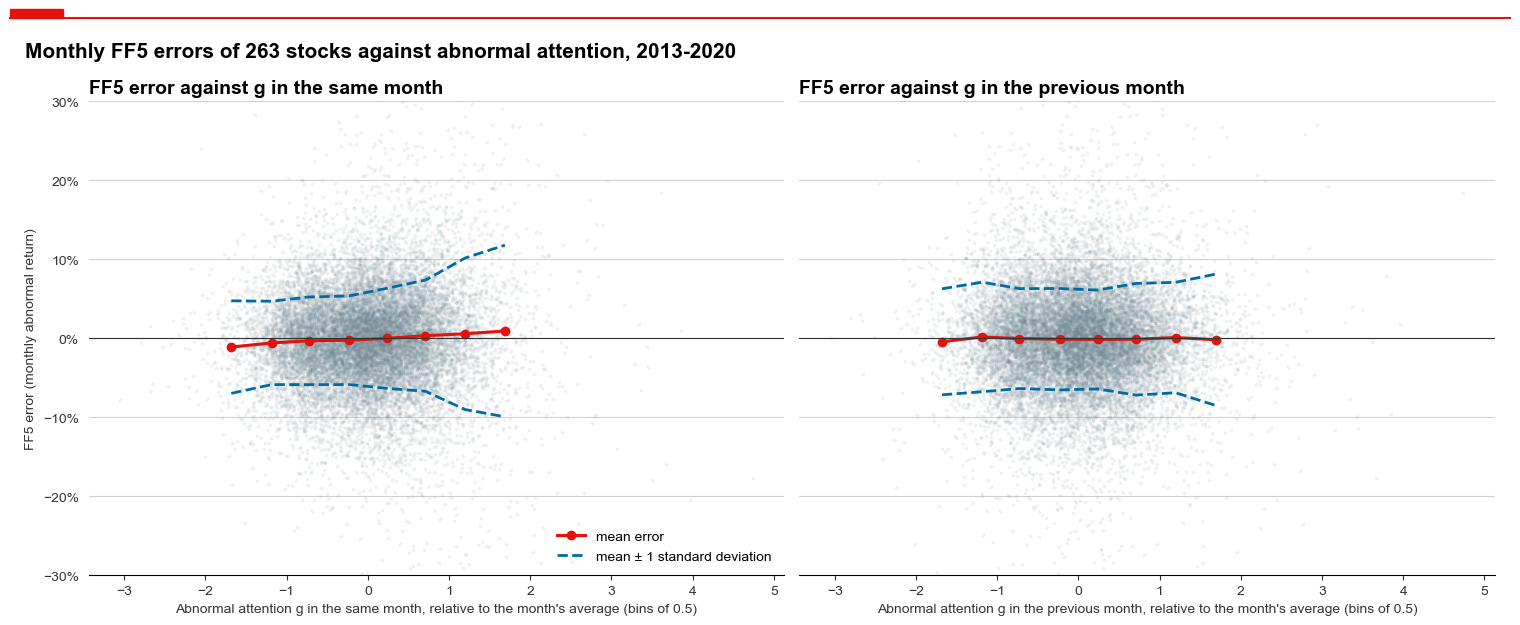

In [ ]:
def ff5_residuals(excess, stocks, start="2013-01", end="2020-07", min_months=36):
    '''Residuals and R2 of each stock's regression of monthly excess returns on the five factors.'''
    residuals, r2 = {}, {}
    for stock in stocks:
        y = excess.loc[start:end, stock].dropna()
        if len(y) >= min_months:
            fit = ols(y, ff5.loc[y.index, FACTORS])
            residuals[stock], r2[stock] = pd.Series(fit.resid, index=y.index), fit.rsquared
    return pd.DataFrame(residuals), pd.Series(r2)


def error_panel(signal, lag):
    '''Pooled stock-months with attention relative to the month's average (same or previous month), excess return and FF5 error.'''
    relative = signal.sub(signal.mean(axis=1), axis=0)                   # removes StockTwits' growth and the gap of late 2017
    data = pd.DataFrame({"g": shift_months(relative, lag).stack(), "return": excess.stack(), "error": residuals.stack()}).dropna()
    data["decile"] = pd.qcut(data["g"].rank(method="first"), 10, labels=range(1, 11))
    return data


residuals, ff5_r2 = ff5_residuals(excess, g.columns[g.notna().sum() >= 24])
print(f"FF5 regressions for {residuals.shape[1]} stocks, {residuals.index[0]} to {residuals.index[-1]}: "
      f"average R2 {ff5_r2.mean():.2f}, residual volatility {residuals.std().mean() * np.sqrt(12):.1%} p.a.")

panels = {(name, timing): error_panel(signal, lag)
          for name, signal in [("abnormal attention g", g), ("attention level", level)]
          for timing, lag in [("same month", 0), ("previous month", 1)]}

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, timing in zip(axes, ["same month", "previous month"]):
    data = panels[("abnormal attention g", timing)]
    bins = pd.cut(data["g"], np.arange(-3, 4.01, 0.5))                   # equal-width bins show the tails
    binned = (data.groupby(bins, observed=True).agg(g=("g", "mean"), mean=("error", "mean"), std=("error", "std"), n=("error", "size"))
                  .query("n >= 100"))

    ax.scatter(data["g"], data["error"], s=3, alpha=0.08, color=ECONOMIST_COLORS[7], rasterized=True)
    ax.plot(binned["g"], binned["mean"], color=ECONOMIST_RED, marker="o", lw=2.2, label="mean error")
    for sign in (1, -1):
        ax.plot(binned["g"], binned["mean"] + sign * binned["std"], color=ECONOMIST_COLORS[0], ls="--", lw=2,
                label="mean +/- 1 standard deviation" if sign == 1 else None)
    ax.axhline(0, color="#333333", lw=0.8)
    ax.set_ylim(-0.3, 0.3)
    ax.set_xlabel(f"Abnormal attention g in the {timing}, relative to the month's average (bins of 0.5)")
    ax.set_title(f"FF5 error against g in the {timing}")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(False, axis="x")
axes[0].set_ylabel("FF5 error (monthly abnormal return)")
axes[0].legend(loc="lower right", fontsize=10)
fig.suptitle(f"Monthly FF5 errors of {residuals.shape[1]} stocks against abnormal attention, 2013-2020", x=0.01, ha="left", fontsize=15, fontweight="bold")
show()

Regressions on the pooled stock-months confirm the plot. Attention is standardised, so slopes are per standard deviation. Standard errors are clustered by month, since all stocks share each month's shocks. The Breusch-Pagan statistic tests whether the squared error depends on attention ($\chi^2(1)$ under homoskedasticity).

In [42]:
rows = {}
for (name, timing), data in panels.items():
    z = (data["g"] - data["g"].mean()) / data["g"].std()
    month = data.index.get_level_values(0).astype(str)
    without_factors = ols(data["return"], z, clusters=month)                # the short regression: FF5 omitted
    on_errors = ols(data["error"], z, clusters=month)                       # after the FF5 factors
    lm, p_value, _, _ = het_breuschpagan(on_errors.resid, sm.add_constant(z.to_numpy()))
    std = data.groupby("decile", observed=True)["error"].std()
    rows[f"{name}, {timing}"] = {"slope, return on g": without_factors.params[1], "t": without_factors.tvalues[1],
                                 "slope, FF5 error on g": on_errors.params[1], "t ": on_errors.tvalues[1],
                                 "Breusch-Pagan LM": lm, "p-value": p_value,
                                 "error std, decile 1": std.iloc[0], "error std, decile 10": std.iloc[-1]}

error_table = pd.DataFrame(rows).T
error_table.style.format({"slope, return on g": "{:.2%}", "slope, FF5 error on g": "{:.2%}", "t": "{:.2f}", "t ": "{:.2f}",
                          "Breusch-Pagan LM": "{:.1f}", "p-value": "{:.3f}", "error std, decile 1": "{:.1%}", "error std, decile 10": "{:.1%}"})

,"slope, return on g",t,"slope, FF5 error on g",t,Breusch-Pagan LM,p-value,"error std, decile 1","error std, decile 10"
"abnormal attention g, same month",0.42%,3.02,0.34%,3.54,184.7,0.000,5.4%,10.4%
"abnormal attention g, previous month",-0.05%,-0.59,-0.03%,-0.38,6.4,0.012,6.8%,7.5%
"attention level, same month",0.34%,3.31,0.07%,1.07,41.9,0.000,5.6%,7.4%
"attention level, previous month",0.18%,2.13,-0.07%,-1.08,4.0,0.047,6.1%,7.0%


**Comments – 4.5**

- **OVB misleads for the attention level.** Without the factors, last month's level seems to predict returns (0.18% per standard deviation, $t = 2.1$). On the FF5 errors the slope is −0.07% ($t = −1.1$). The level is correlated with factor exposures (large growth firms), whose returns the short regression credits to attention. In the same month the slope falls from 0.34% to 0.07%.
- **For abnormal attention the bias is small:** in the same month the slope falls only from 0.42% to 0.34% and stays significant ($t = 3.5$), so attention shocks carry information that FF5 misses within the month. With last month's $g$ both slopes are zero. In the plot the mean error (red) rises gently in the left panel, from about −1% to +1%, and is flat in the right one: small next to the dispersion.
- **Heteroskedasticity is strong.** The error dispersion doubles from the lowest to the highest decile of same-month attention (5.4% to 10.4% a month, the fan of the left panel; Breusch-Pagan 185, $p \approx 0$), and last month's attention still predicts it, more weakly (6.8% to 7.5%, $p = 0.01$). Hence the Newey-West and clustered standard errors of Task #4. Economically, attention measures **risk, not expected return**: a suddenly discussed stock has news, and its next return is more uncertain, not higher.

## Conclusion
Our answer to the hedge fund in one figure: on the left, what a fund would have earned by sorting stocks on Twitter attention. On the right, what attention says about the returns that come with it and after it.

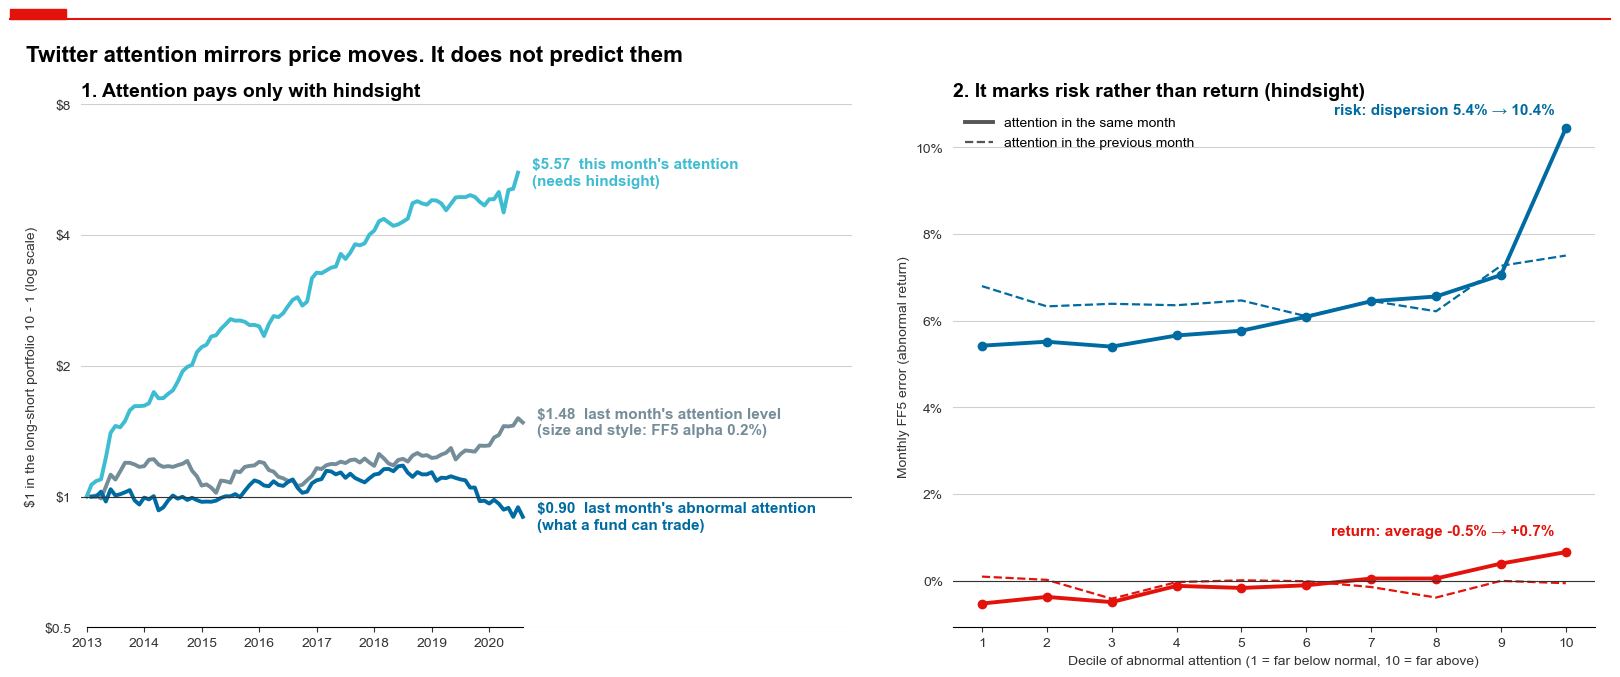

In [ ]:
def value_of_dollar(spread):
    '''Value of $1 in a monthly long-short return series, indexed by the end of each month in years.'''
    value = pd.concat([pd.Series([1.0], index=[spread.index[0] - 1]), (1 + spread).cumprod()])
    return value.set_axis(value.index.year + value.index.month / 12)


fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={"width_ratios": [1.2, 1]})

# Left: the 10 - 1 portfolio, sorted on this month's attention (hindsight) or last month's (tradable)
lines = [(portfolios[("g", "same month")], ECONOMIST_COLORS[1], "this month's attention\n(needs hindsight)"),
         (portfolios[("level", "previous month")], ECONOMIST_COLORS[7],
          f"last month's attention level\n(size and style: FF5 alpha {spread_table.loc['level, previous month', 'FF5 alpha']:.1%})"),
         (portfolios[("g", "previous month")], ECONOMIST_COLORS[0], "last month's abnormal attention\n(what a fund can trade)")]
for p, color, label in lines:
    value = value_of_dollar(p["10 - 1"])
    axes[0].plot(value.index, value, color=color, lw=2.8)
    axes[0].annotate(f"${value.iloc[-1]:.2f}  {label}", (value.index[-1], value.iloc[-1]), xytext=(10, 0),
                     textcoords="offset points", va="center", color=color, fontsize=11, fontweight="bold")
axes[0].axhline(1, color="#333333", lw=0.8)
axes[0].set_yscale("log")
axes[0].set_yticks([0.5, 1, 2, 4, 8], labels=["$0.5", "$1", "$2", "$4", "$8"])
axes[0].minorticks_off()
axes[0].set_xlim(2012.9, 2026.3)                                         # room for the labels
axes[0].set_xticks(range(2013, 2021))
axes[0].spines["bottom"].set_bounds(2013, value.index[-1])
axes[0].set_title("1. Attention pays only with hindsight")
axes[0].set_ylabel("$1 in the long-short portfolio 10 - 1 (log scale)")
axes[0].grid(False, axis="x")

# Right: average and dispersion of the FF5 error by decile of abnormal attention
for timing, style, width in [("same month", "-", 2.8), ("previous month", "--", 1.6)]:
    by = panels[("abnormal attention g", timing)].groupby("decile", observed=True)["error"].agg(["mean", "std"])
    deciles = by.index.astype(int)
    axes[1].plot(deciles, by["std"], color=ECONOMIST_COLORS[0], ls=style, lw=width, marker="o" if timing == "same month" else None)
    axes[1].plot(deciles, by["mean"], color=ECONOMIST_RED, ls=style, lw=width, marker="o" if timing == "same month" else None)
    if timing == "same month":
        axes[1].annotate(f"risk: dispersion {by['std'].iloc[0]:.1%} → {by['std'].iloc[-1]:.1%}", (10, by["std"].iloc[-1]), xytext=(-8, 8),
                         textcoords="offset points", ha="right", va="bottom", color=ECONOMIST_COLORS[0], fontsize=11, fontweight="bold")
        axes[1].annotate(f"return: average {by['mean'].iloc[0]:+.1%} → {by['mean'].iloc[-1]:+.1%}", (10, by["mean"].iloc[-1]), xytext=(-8, 10),
                         textcoords="offset points", ha="right", va="bottom", color=ECONOMIST_RED, fontsize=11, fontweight="bold")
axes[1].plot([], [], color="#555555", lw=2.8, label="attention in the same month")
axes[1].plot([], [], color="#555555", lw=1.6, ls="--", label="attention in the previous month")
axes[1].legend(loc="upper left")
axes[1].axhline(0, color="#333333", lw=0.8)
axes[1].set_xticks(range(1, 11))
axes[1].yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
axes[1].set_title("2. It marks risk rather than return (hindsight)")
axes[1].set_xlabel("Decile of abnormal attention (1 = far below normal, 10 = far above)")
axes[1].set_ylabel("Monthly FF5 error (abnormal return)")
axes[1].grid(False, axis="x")
fig.suptitle("Twitter attention mirrors price moves. It does not predict them", x=0.01, ha="left", fontsize=16, fontweight="bold")
show()

**Left: attention pays only with hindsight.** Sorted on this month's attention, the long-short portfolio turns \$1 into \$5.57 (2.0% a month, $t = 5.0$). Sorted on last month's attention, the information a fund actually has, it ends at \$0.90 ($t = −0.4$), and betting on extreme attention in either direction worked in 2013-2016 but not since (4.4). The most discussed stocks did earn \$1.48, but as large growth firms, which the five factors explain (omitted-variable bias).

**Right: attention marks risk rather than return.** When attention is unusually high in the same month, abnormal returns fan out to twice their usual dispersion (5.4% to 10.4% a month) while their average barely moves. This, like the left panel, uses hindsight. What a fund could use is last month's attention, and it still points to more dispersion, though much less: 7.5% in the top decile against about 6.3% in the middle (Breusch-Pagan $p = 0.012$). Since the FF5 betas are estimated over the full sample, even this effect should be confirmed with rolling betas.

**For the hedge fund**, Twitter attention is therefore no factor in this form, but at most a weak risk signal, a candidate for position sizing rather than stock picking. The answer rests on the 5.08 million messages left after cleaning (Task #1), attributed to stocks through their cashtags, and on Twitter-RoBERTa, which reads StockTwits posts better than FinBERT (81.5% against 76.3% of directions right, Task #3). Three limits call for a fairer test: attention outside the 25 collected symbols is measured only through co-mentions, today's S&P 500 introduces survivorship bias, and monthly portfolios miss price pressure that reverses within days or weeks. Complete StockTwits streams, historical index constituents and weekly or daily horizons would address them. A sentiment model fine-tuned on labelled StockTwits messages would sharpen the sentiment measures.